# Matching inference

In [21]:
import pandas as pd
# Load data into pandas DataFrame from "/lakehouse/default/Files/output/inference/matching_high/calendar2_1year_high/cohort_dynamic.csv"
df = pd.read_csv("/lakehouse/default/Files/output/inference/matching_high/calendar2_1year_high/cohort_dynamic.csv")
display(df)


StatementMeta(, 75279161-88cc-4d7d-b5c3-bf0d4506d969, 23, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 568eca2d-ae8a-4080-9bcc-4e356a68ca48)

In [22]:
import matplotlib.pyplot as plt
import warnings
import pandas as pd
warnings.filterwarnings("ignore")

StatementMeta(, 75279161-88cc-4d7d-b5c3-bf0d4506d969, 24, Finished, Available, Finished, False)

In [23]:
%run ./matching_inference-3

StatementMeta(, 75279161-88cc-4d7d-b5c3-bf0d4506d969, 25, Finished, Available, Finished, True)

## Load Data 

### Adopt matching result

In [24]:
# Change here !!!
match_method = "calendar2"
# option: calendar, calendar2, summary_1, summary_2, summary_3, summary_4, summary_season, summary_season_2, time_series
# check: time_series, calendar(matching result is not that good), summary_4, summary_season_2


# 1. Read data
matches = pd.read_parquet(f"/lakehouse/default/Files/output/matching_high/{match_method}/matches")
month_result= pd.read_parquet("/lakehouse/default/Files/month_data")

# 2. create matched panel
df = build_matched_panel(matches, month_result)
# df
# df["top3_mean_consumption"] = pd.to_numeric(df["top3_mean_consumption"], errors="coerce")

StatementMeta(, 75279161-88cc-4d7d-b5c3-bf0d4506d969, 26, Finished, Available, Finished, False)

StatementMeta(, 75279161-88cc-4d7d-b5c3-bf0d4506d969, 27, Finished, Available, Finished, False)


===== TRANSFORMED EVENT TIME DATA =====
                       aID   cohort TIDPUNKT  treatment  event_time  \
869261  735999166200003237  2025-03  2023-01          1         -26   
869273  735999166200003237  2025-03  2023-02          1         -25   
869245  735999166200003237  2025-03  2023-03          1         -24   
869217  735999166200003237  2025-03  2023-11          1         -16   
869251  735999166200003237  2025-03  2023-12          1         -15   
...                    ...      ...      ...        ...         ...   
820578  735999166200006467  2025-03  2025-12          0           9   
820713  735999166200006467  2025-03  2026-01          0          10   
820714  735999166200006467  2025-03  2026-01          0          10   
820683  735999166200006467  2025-03  2026-02          0          11   
820684  735999166200006467  2025-03  2026-02          0          11   

        cohort_event_month  target_month_flag  new_event_time  
869261                   1                

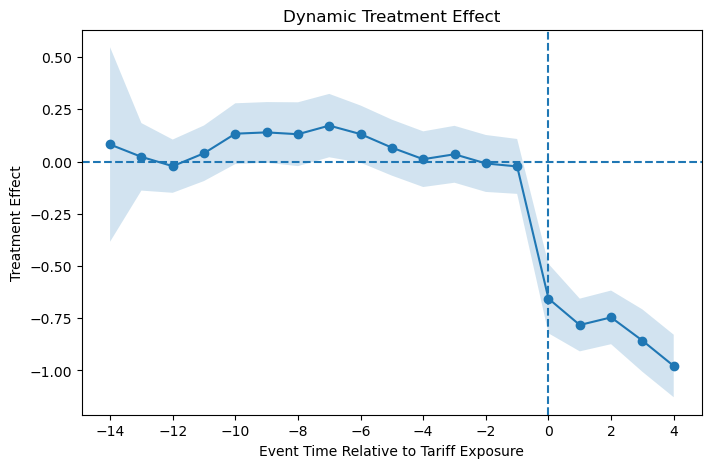


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 0.0668561220027007, 't_stat': 3.2541766829734815, 'p_value': 0.00767802382231758}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': -0.8040355061911744, 'SE': 0.05432252092098207, 't_stat': -14.801144949821644, 'p_value': 0.0, 'CI_low': -0.9105076471962992, 'CI_high': -0.6975633651860496, 'n_periods': 5}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': -0.7281611347918503, 'SE': 0.03757325274600569, 't_stat': -19.379773684067295, 'p_value': 0.0, 'CI_low': -0.8018047101740214, 'CI_high': -0.6545175594096792, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  new_event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03             -12 -0.0914 0.1045 -0.8749   0.3816        620   
1    2025-03             -11  0.0366 0.1076  0.3397   0.7340        620   
2    2025-03             -10  0.1234 0.1132  1.0897   0.2758        617   
3    20

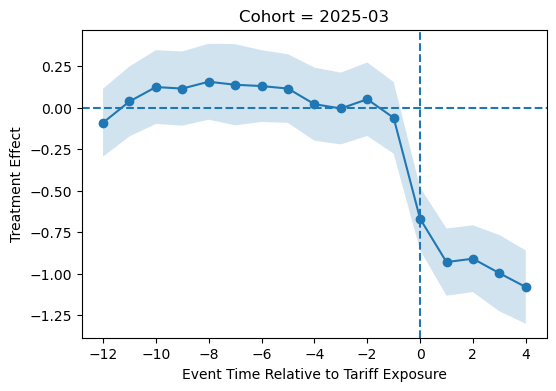

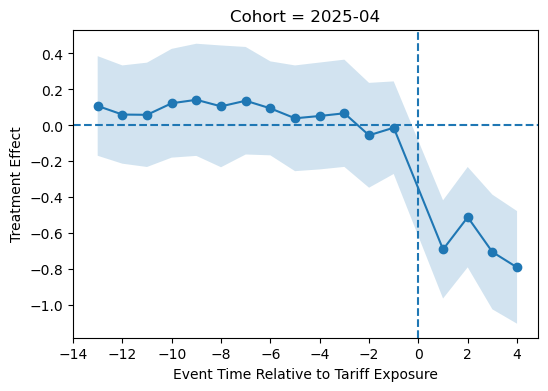

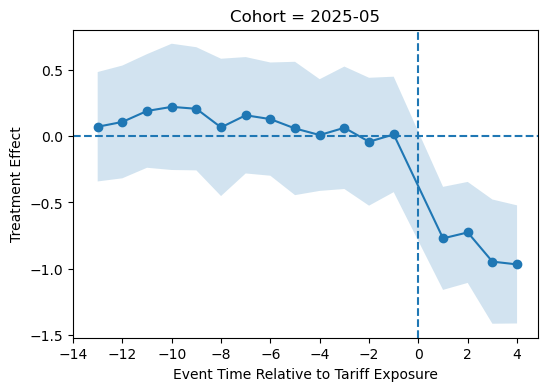

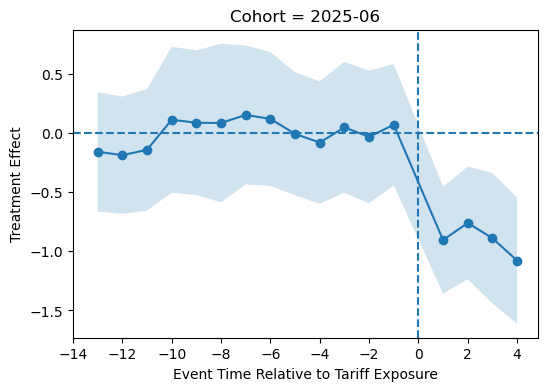

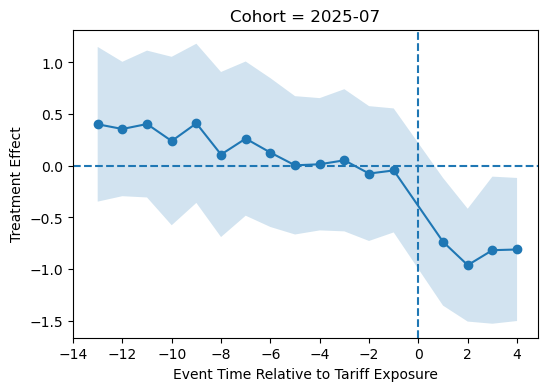

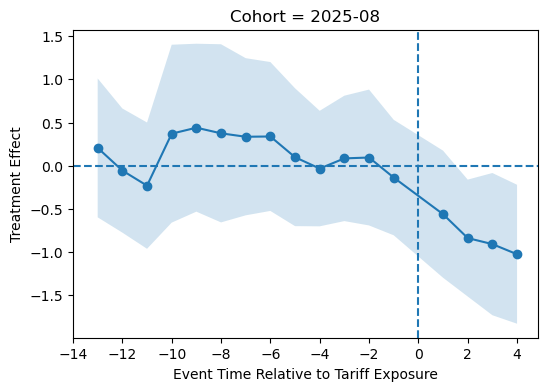

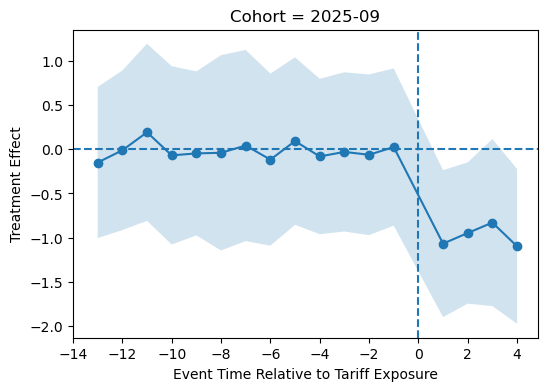

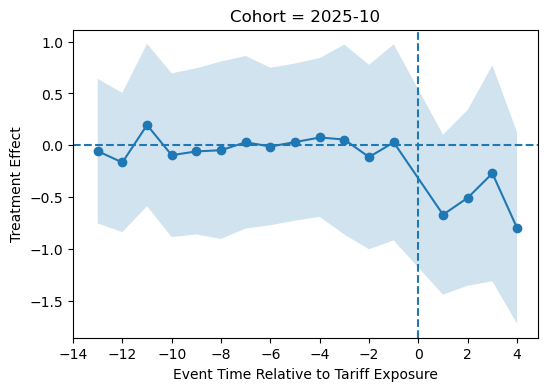

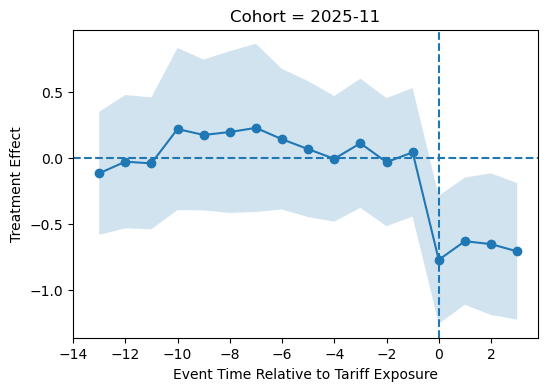

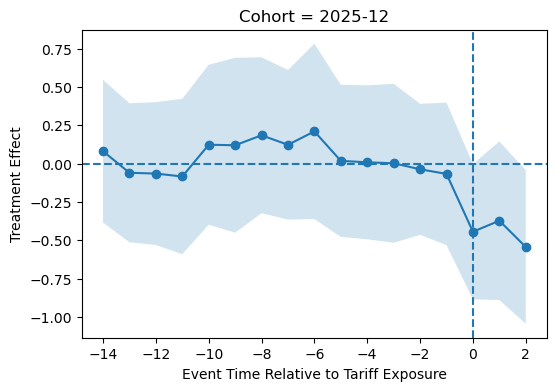

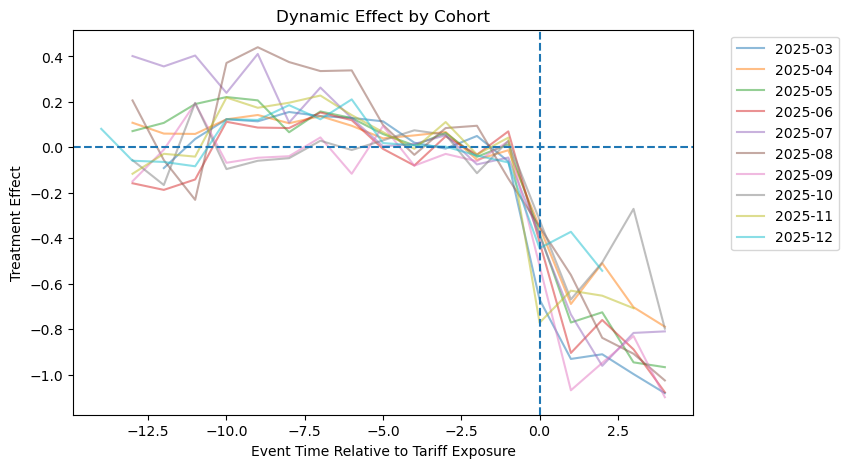


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort     ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 -0.9183 0.0689 -13.3368   0.0000 -1.0532  -0.7833          5
1  2025-04 -0.6730 0.0587 -11.4744   0.0000 -0.7880  -0.5581          4
2  2025-05 -0.8526 0.0610 -13.9782   0.0000 -0.9722  -0.7331          4
3  2025-06 -0.9079 0.0653 -13.9045   0.0000 -1.0359  -0.7799          4
4  2025-07 -0.8310 0.0473 -17.5822   0.0000 -0.9236  -0.7383          4
5  2025-08 -0.8336 0.0985  -8.4610   0.0000 -1.0267  -0.6405          4
6  2025-09 -0.9869 0.0615 -16.0461   0.0000 -1.1075  -0.8664          4
7  2025-10 -0.5612 0.1136  -4.9395   0.0000 -0.7839  -0.3385          4
8  2025-11 -0.6909 0.0315 -21.9407   0.0000 -0.7526  -0.6291          4
9  2025-12 -0.4530 0.0497  -9.1088   0.0000 -0.5504  -0.3555          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort     ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 -0.8373 0.0838  -9.9916   0.000

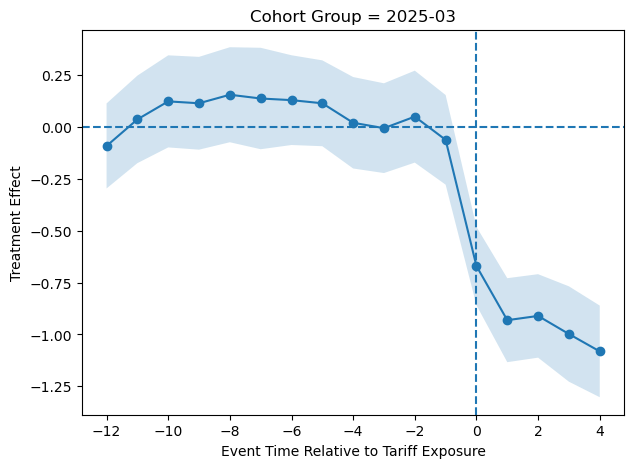

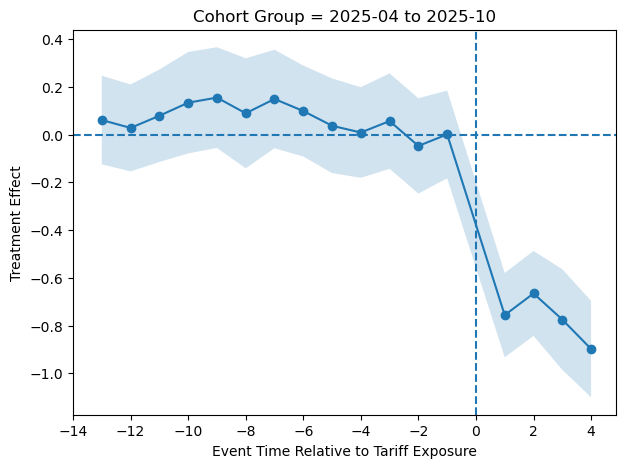

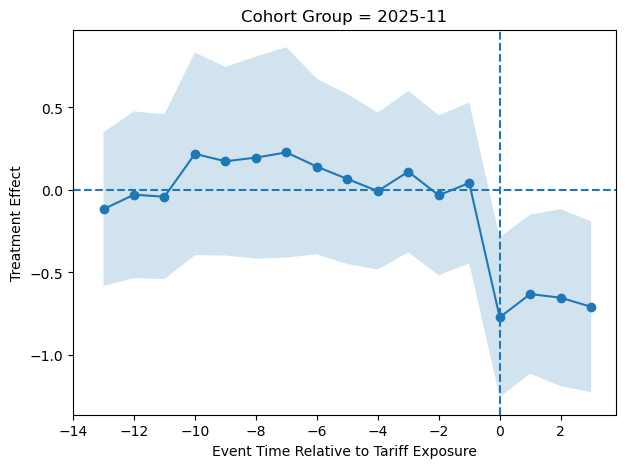

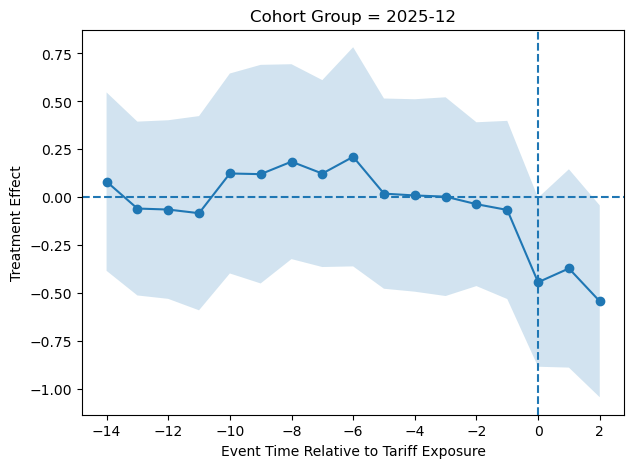

✅ Results saved to: /lakehouse/default/Files/output/inference/matching_high/calendar2_high


In [25]:
df_high = df[df["price"]== "high"] 
results_high = run_full_analysis(df_high)
save_results(results_high, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_high")

StatementMeta(, 75279161-88cc-4d7d-b5c3-bf0d4506d969, 28, Finished, Available, Finished, False)


===== TRANSFORMED EVENT TIME DATA =====
                       aID   cohort TIDPUNKT  treatment  event_time  \
869257  735999166200003237  2025-03  2023-01          1         -26   
869225  735999166200003237  2025-03  2023-02          1         -25   
869195  735999166200003237  2025-03  2023-03          1         -24   
869196  735999166200003237  2025-03  2023-04          1         -23   
869267  735999166200003237  2025-03  2023-05          1         -22   
...                    ...      ...      ...        ...         ...   
617032  735999166200004210  2025-03  2024-08          0          -7   
617080  735999166200004210  2025-03  2024-09          0          -6   
617009  735999166200004210  2025-03  2024-10          0          -5   
617063  735999166200004210  2025-03  2024-11          0          -4   
617003  735999166200004210  2025-03  2024-12          0          -3   

        cohort_event_month  target_month_flag  new_event_time  
869257                   1                

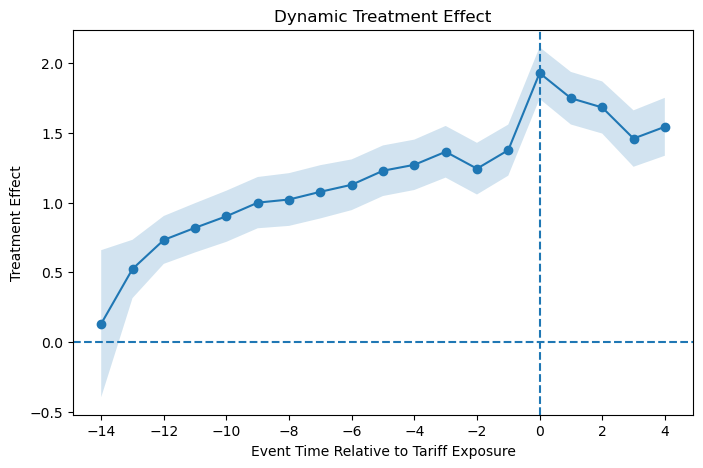


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 1.097328199356178, 't_stat': 18.142742160847952, 'p_value': 1.5164315760891797e-09}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': 1.6727779076346632, 'SE': 0.0818109267184065, 't_stat': 20.44687641043807, 'p_value': 0.0, 'CI_low': 1.5124284912665864, 'CI_high': 1.83312732400274, 'n_periods': 5}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': 1.7868663067347663, 'SE': 0.07380695732455257, 't_stat': 24.209998237393112, 'p_value': 0.0, 'CI_low': 1.6422046703786433, 'CI_high': 1.9315279430908894, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  new_event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03             -12  1.0742 0.1467  7.3203   0.0000        620   
1    2025-03             -11  1.2445 0.1507  8.2592   0.0000        620   
2    2025-03             -10  1.2019 0.1517  7.9216   0.0000        617   
3    2025-03     

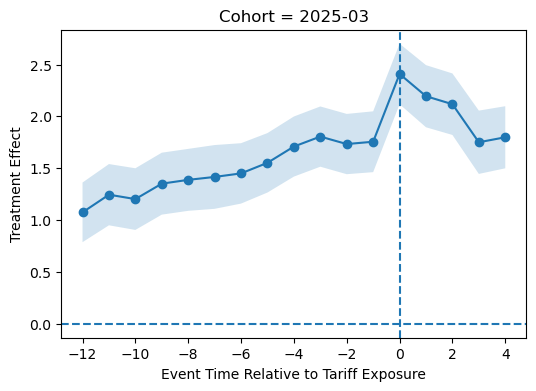

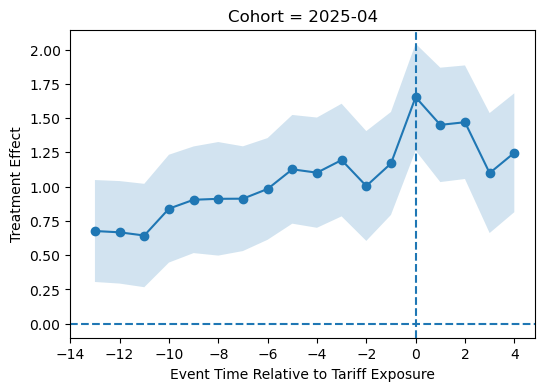

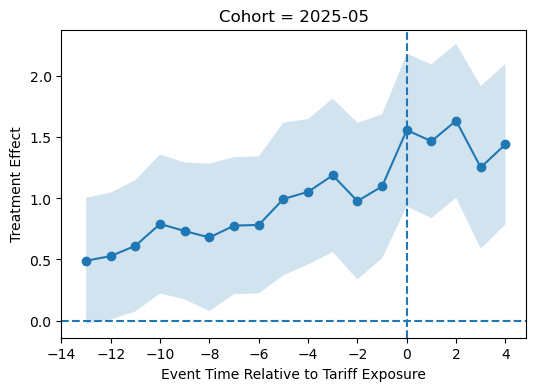

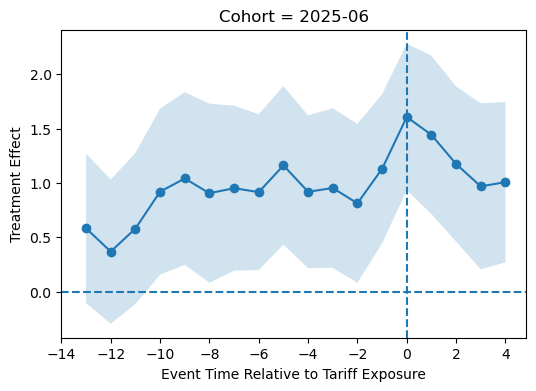

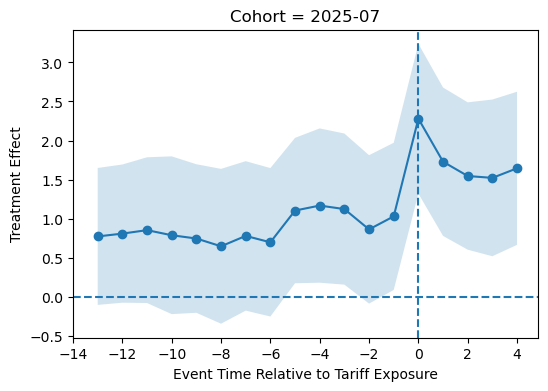

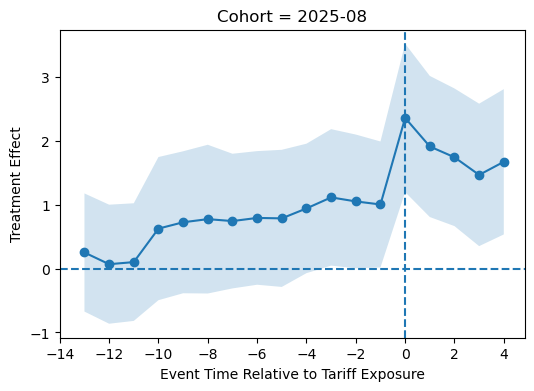

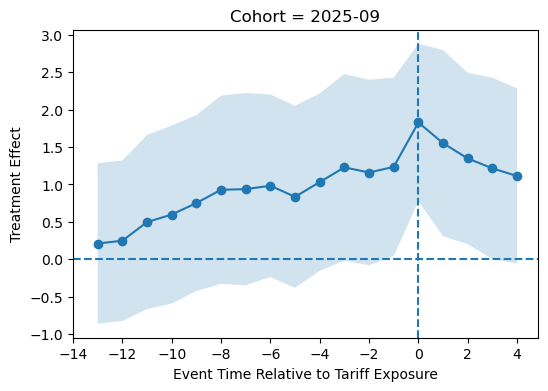

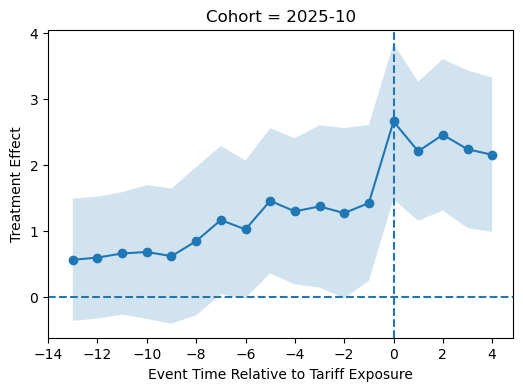

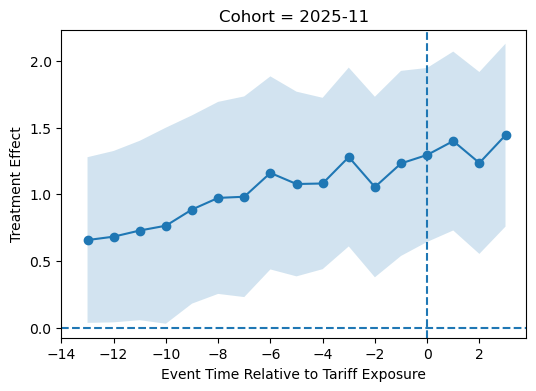

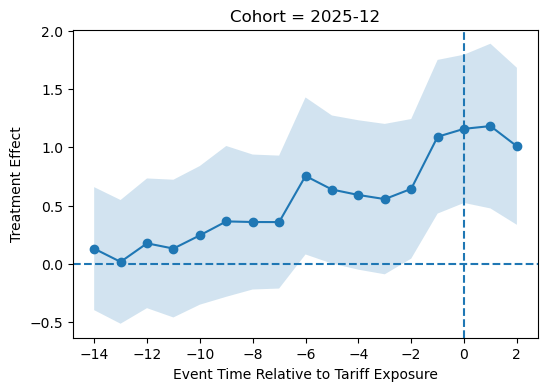

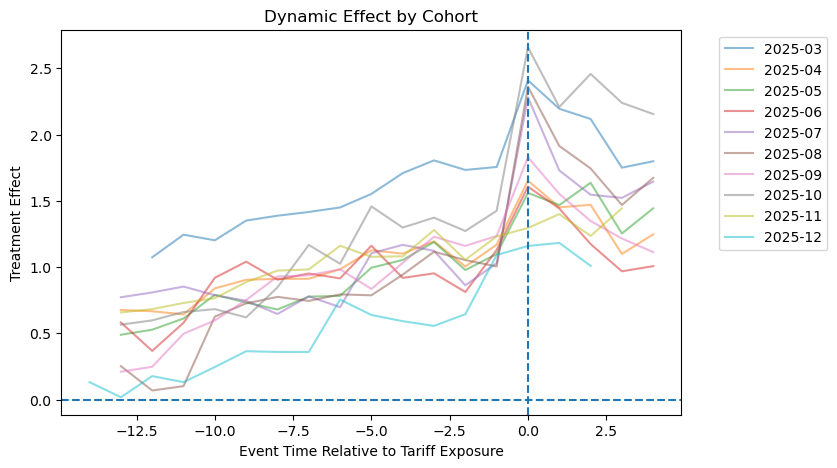


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.0537 0.1239 16.5698   0.0000  1.8108   2.2967          5
1  2025-04 1.3838 0.0959 14.4294   0.0000  1.1959   1.5718          5
2  2025-05 1.4720 0.0645 22.8213   0.0000  1.3455   1.5984          5
3  2025-06 1.2396 0.1240  9.9946   0.0000  0.9965   1.4827          5
4  2025-07 1.7444 0.1389 12.5599   0.0000  1.4722   2.0166          5
5  2025-08 1.8322 0.1503 12.1925   0.0000  1.5376   2.1267          5
6  2025-09 1.4114 0.1276 11.0651   0.0000  1.1614   1.6614          5
7  2025-10 2.3433 0.0941 24.8913   0.0000  2.1588   2.5279          5
8  2025-11 1.3433 0.0476 28.2363   0.0000  1.2501   1.4366          4
9  2025-12 1.1170 0.0542 20.5961   0.0000  1.0107   1.2233          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.2401 0.0872 25.6835   0.0000  2.0691   2.4110        

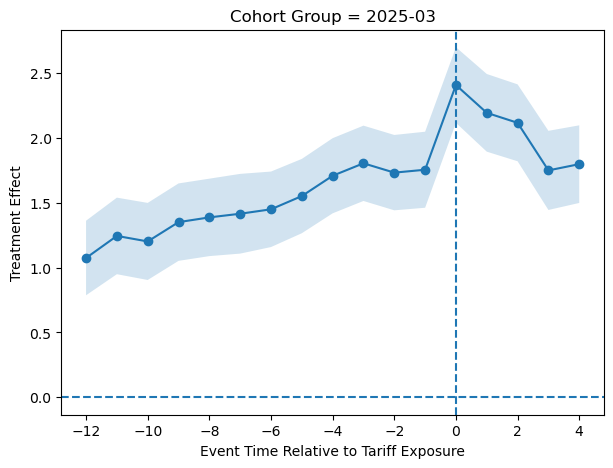

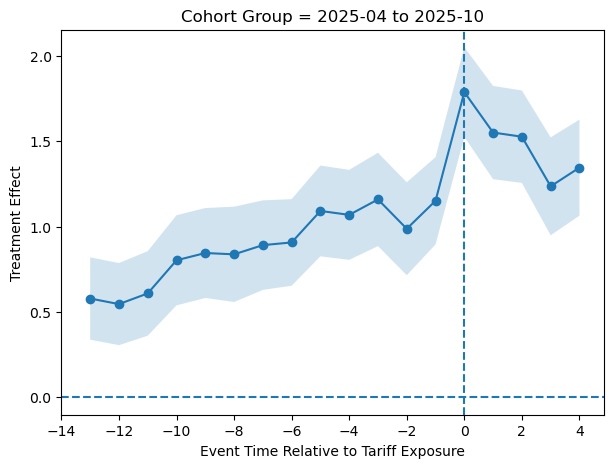

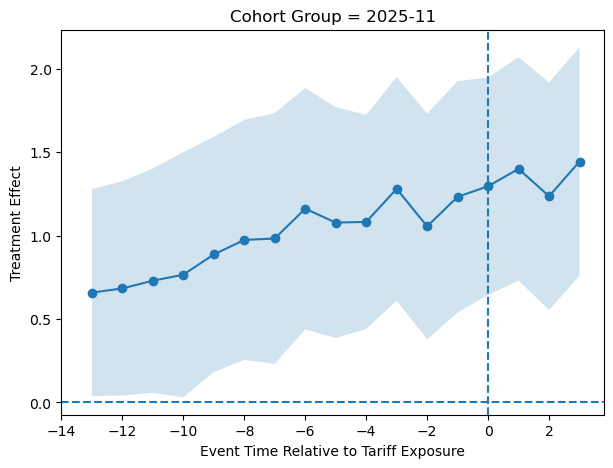

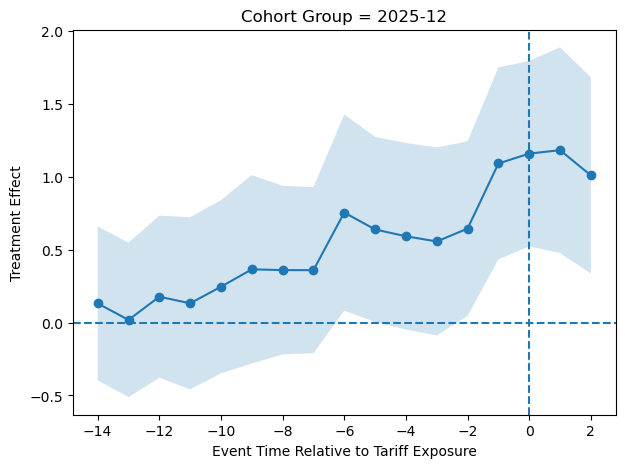

✅ Results saved to: /lakehouse/default/Files/output/inference/matching_high/calendar2_all


In [26]:
df_all = df[df["price"]== "all"] 
results_all = run_full_analysis(df_all)
save_results(results_all, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_all")

StatementMeta(, 75279161-88cc-4d7d-b5c3-bf0d4506d969, 29, Finished, Available, Finished, False)


===== TRANSFORMED EVENT TIME DATA =====
                       aID   cohort TIDPUNKT  treatment  event_time  \
869230  735999166200003237  2025-03  2023-01          1         -26   
869265  735999166200003237  2025-03  2023-02          1         -25   
869248  735999166200003237  2025-03  2023-03          1         -24   
869220  735999166200003237  2025-03  2023-04          1         -23   
869222  735999166200003237  2025-03  2023-05          1         -22   
...                    ...      ...      ...        ...         ...   
617069  735999166200004210  2025-03  2024-08          0          -7   
617019  735999166200004210  2025-03  2024-09          0          -6   
617053  735999166200004210  2025-03  2024-10          0          -5   
617011  735999166200004210  2025-03  2024-11          0          -4   
617051  735999166200004210  2025-03  2024-12          0          -3   

        cohort_event_month  target_month_flag  new_event_time  
869230                   1                

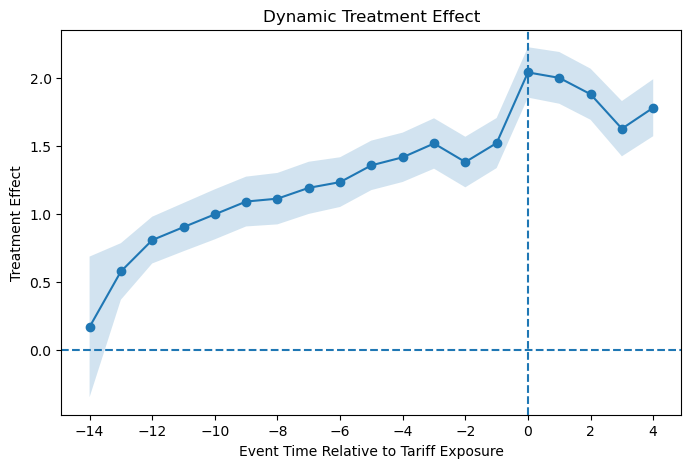


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 1.2108357884489782, 't_stat': 17.800457565047246, 'p_value': 1.8579949584950835e-09}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': 1.8653224912922568, 'SE': 0.07521653561502248, 't_stat': 24.79936726731813, 'p_value': 0.0, 'CI_low': 1.7178980814868128, 'CI_high': 2.012746901097701, 'n_periods': 5}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': 1.9732216858387972, 'SE': 0.04821036369895138, 't_stat': 40.92940883334835, 'p_value': 0.0, 'CI_low': 1.8787293729888526, 'CI_high': 2.067713998688742, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  new_event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03             -12  1.1850 0.1474  8.0411   0.0000        620   
1    2025-03             -11  1.3604 0.1513  8.9911   0.0000        620   
2    2025-03             -10  1.3405 0.1531  8.7555   0.0000        617   
3    2025-03    

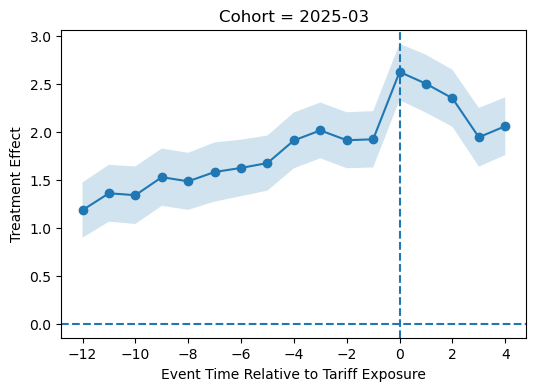

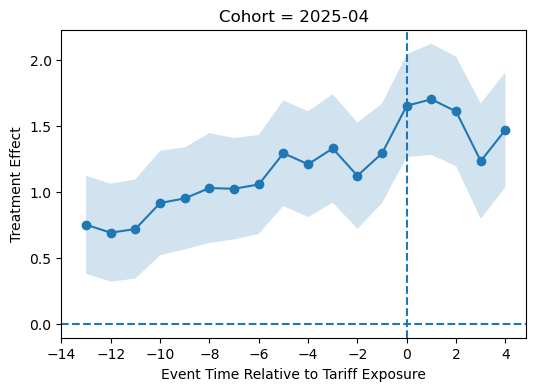

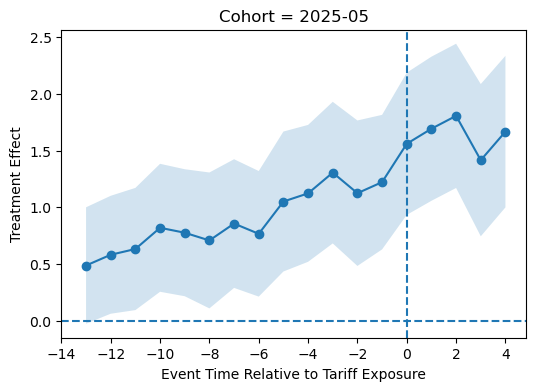

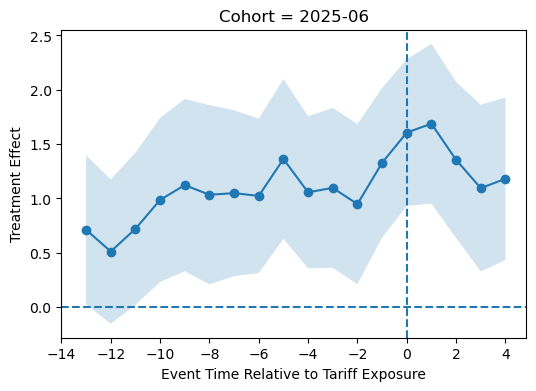

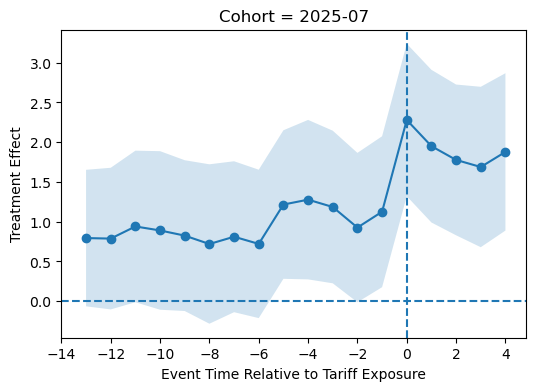

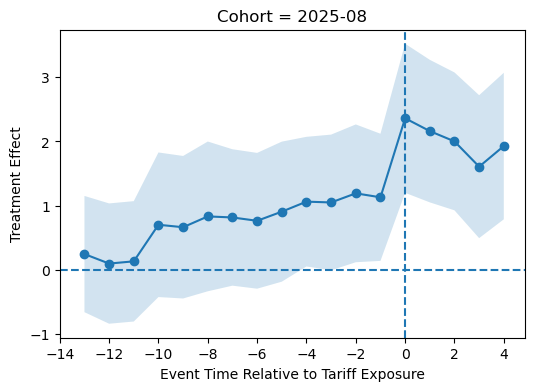

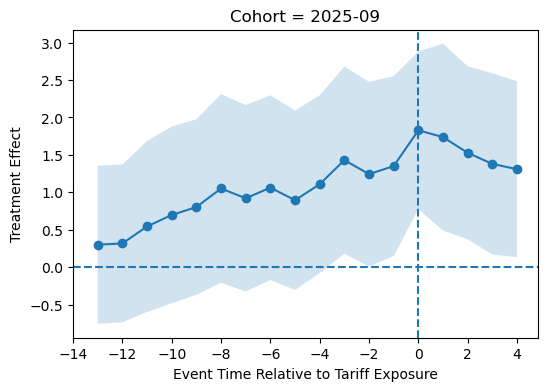

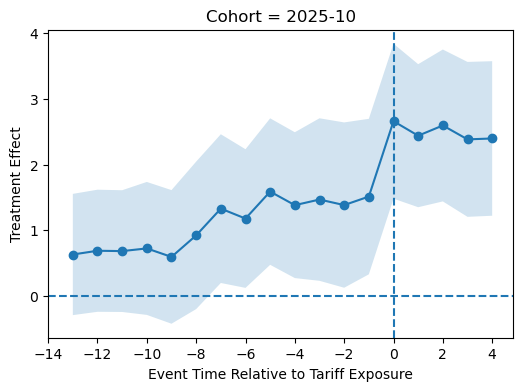

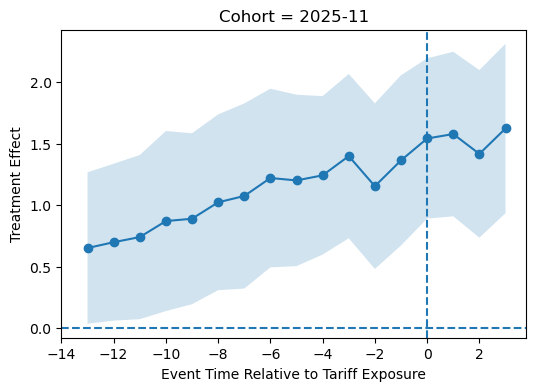

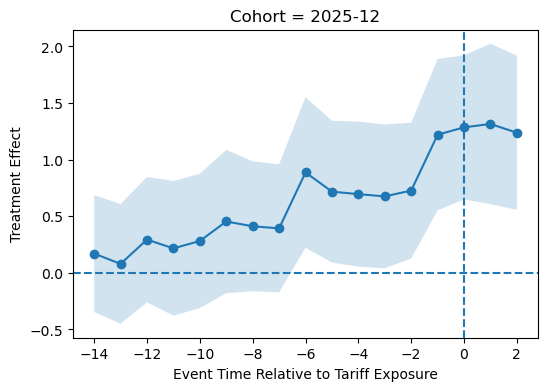

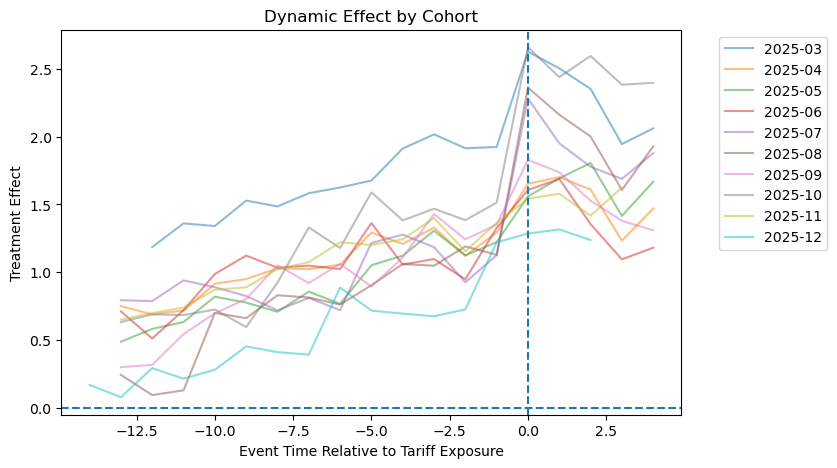


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.2971 0.1292 17.7765   0.0000  2.0438   2.5504          5
1  2025-04 1.5331 0.0844 18.1616   0.0000  1.3677   1.6986          5
2  2025-05 1.6278 0.0660 24.6698   0.0000  1.4985   1.7571          5
3  2025-06 1.3850 0.1156 11.9811   0.0000  1.1584   1.6116          5
4  2025-07 1.9149 0.1015 18.8583   0.0000  1.7159   2.1139          5
5  2025-08 2.0113 0.1257 16.0019   0.0000  1.7649   2.2576          5
6  2025-09 1.5560 0.1000 15.5592   0.0000  1.3600   1.7521          5
7  2025-10 2.4938 0.0558 44.7204   0.0000  2.3845   2.6031          5
8  2025-11 1.5405 0.0444 34.6852   0.0000  1.4535   1.6276          4
9  2025-12 1.2795 0.0226 56.5730   0.0000  1.2352   1.3239          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.4935 0.0795 31.3797   0.0000  2.3378   2.6493        

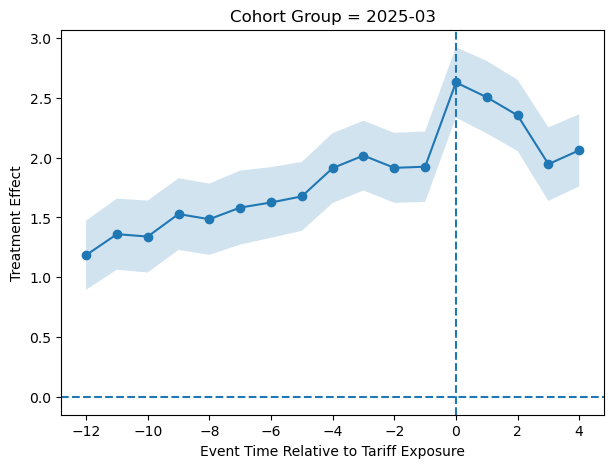

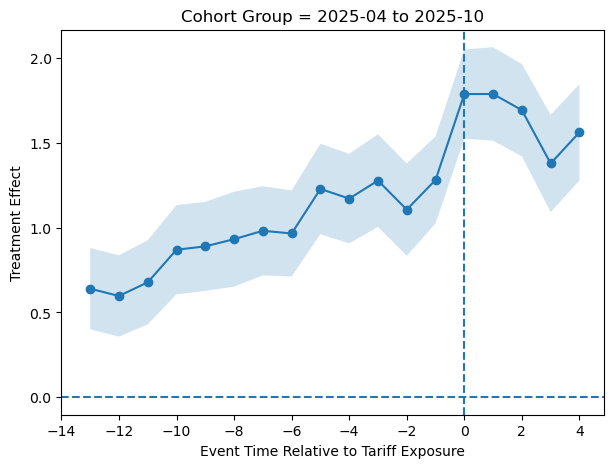

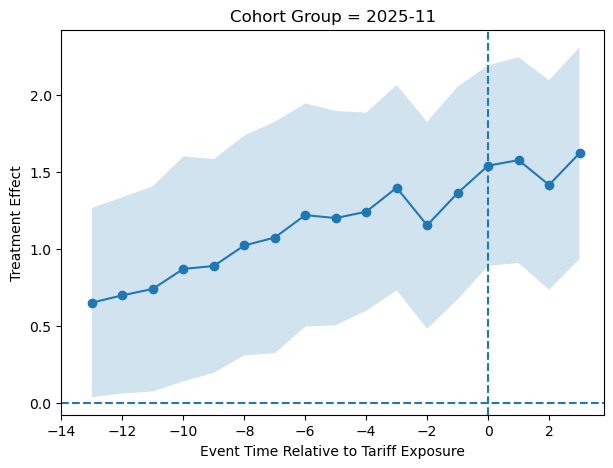

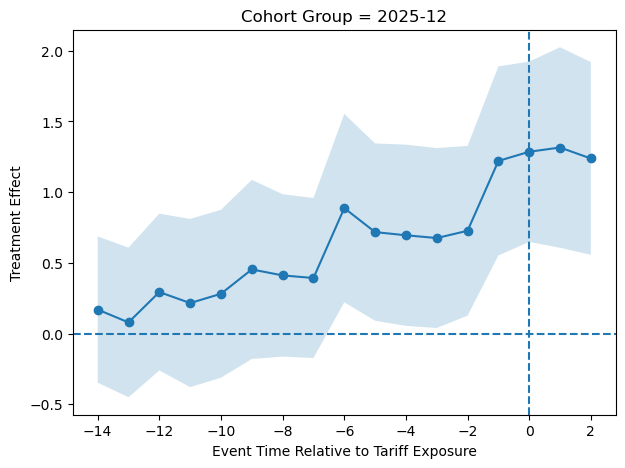

✅ Results saved to: /lakehouse/default/Files/output/inference/matching_high/calendar2_low


In [27]:
df_low = df[df["price"]== "low"] 
results_low = run_full_analysis(df_low)
save_results(results_low, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_low")

In [28]:
# Change here !!!
match_method = "calendar2_1year"
# option: calendar, calendar2, summary_1, summary_2, summary_3, summary_4, summary_season, summary_season_2, time_series
# check: time_series, calendar(matching result is not that good), summary_4, summary_season_2


# 1. Read data
matches = pd.read_parquet(f"/lakehouse/default/Files/output/matching_high/{match_method}/matches")
month_result= pd.read_parquet("/lakehouse/default/Files/month_data")

# 2. create matched panel
df = build_matched_panel(matches, month_result)

StatementMeta(, 75279161-88cc-4d7d-b5c3-bf0d4506d969, 30, Finished, Available, Finished, False)

StatementMeta(, 75279161-88cc-4d7d-b5c3-bf0d4506d969, 31, Finished, Available, Finished, False)


===== TRANSFORMED EVENT TIME DATA =====
                       aID   cohort TIDPUNKT  treatment  event_time  \
909919  735999166200003237  2025-03  2023-01          1         -26   
909931  735999166200003237  2025-03  2023-02          1         -25   
909903  735999166200003237  2025-03  2023-03          1         -24   
909875  735999166200003237  2025-03  2023-11          1         -16   
909909  735999166200003237  2025-03  2023-12          1         -15   
...                    ...      ...      ...        ...         ...   
805176  735999166200013533  2025-03  2025-01          0          -2   
805223  735999166200013533  2025-03  2025-02          0          -1   
805216  735999166200013533  2025-03  2025-03          0           0   
805244  735999166200013533  2025-03  2025-11          0           8   
805192  735999166200013533  2025-03  2025-12          0           9   

        cohort_event_month  target_month_flag  new_event_time  
909919                   1                

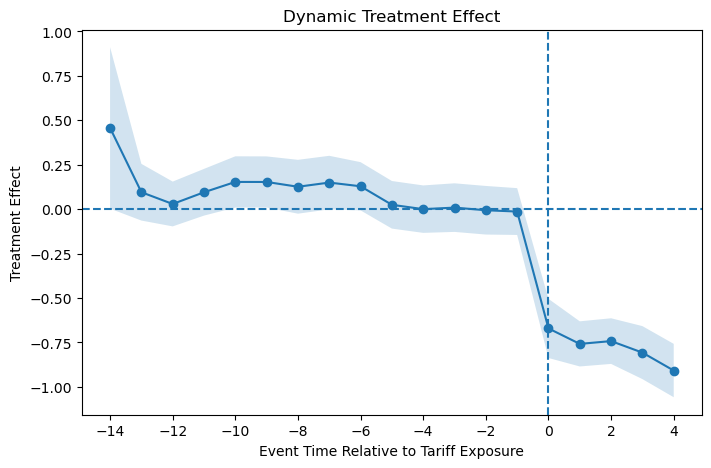


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 0.07085447452654463, 't_stat': 3.5521254497068497, 'p_value': 0.004535108996613898}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': -0.7771946720302901, 'SE': 0.03927863330001419, 't_stat': -19.786703526418506, 'p_value': 0.0, 'CI_low': -0.854180793298318, 'CI_high': -0.7002085507622623, 'n_periods': 5}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': -0.7236998326203983, 'SE': 0.026771676418918432, 't_stat': -27.03229417897004, 'p_value': 0.0, 'CI_low': -0.7761723184014784, 'CI_high': -0.6712273468393182, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  new_event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03             -12 -0.0425 0.1030 -0.4130   0.6796        620   
1    2025-03             -11  0.1051 0.1063  0.9884   0.3229        620   
2    2025-03             -10  0.1053 0.1122  0.9385   0.3480        617   
3    2

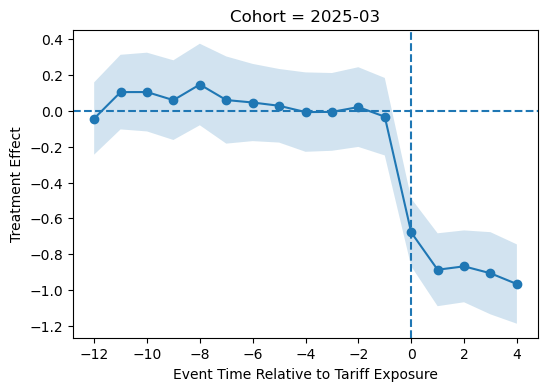

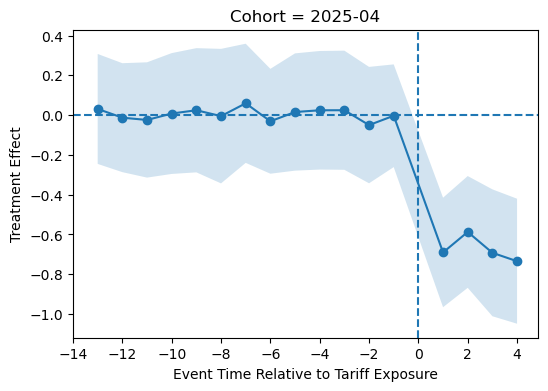

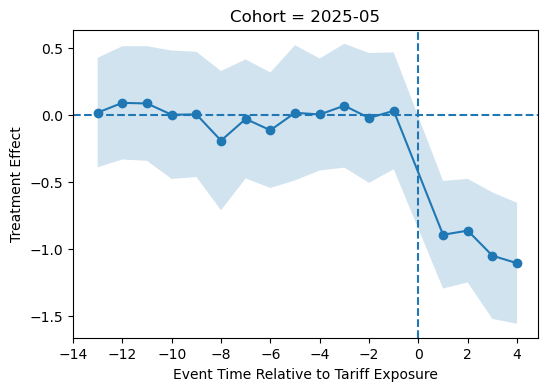

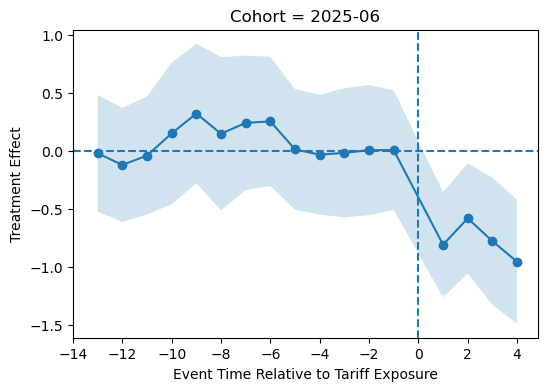

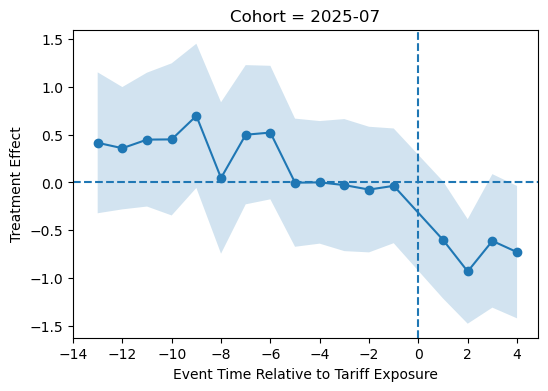

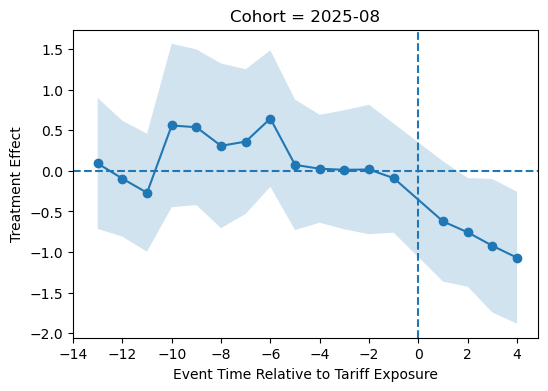

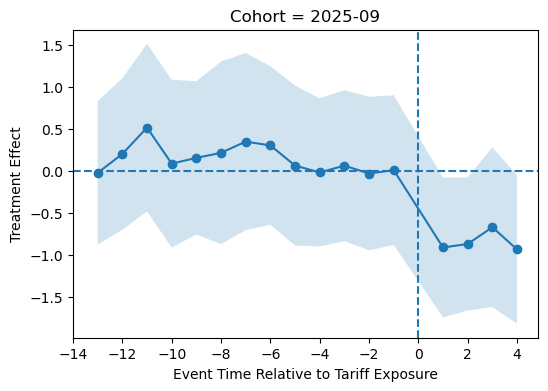

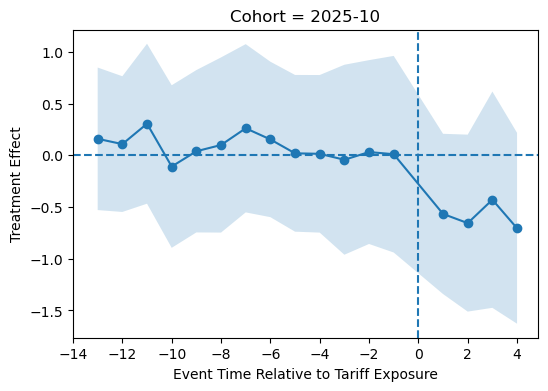

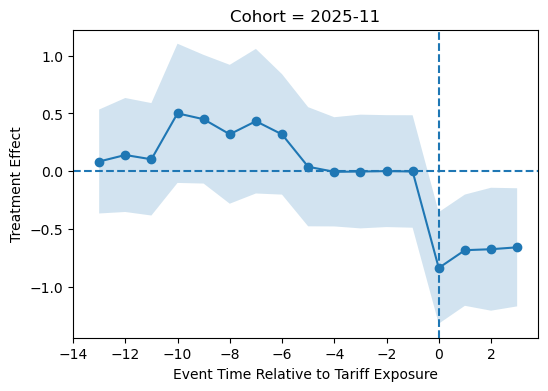

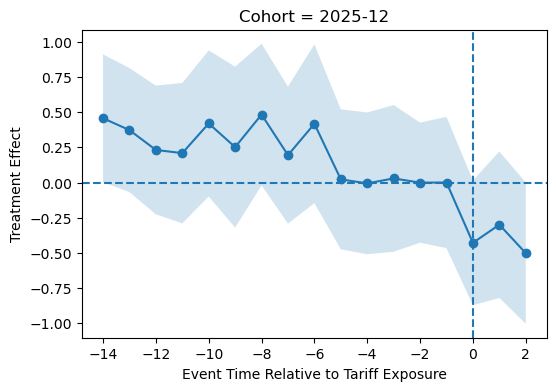

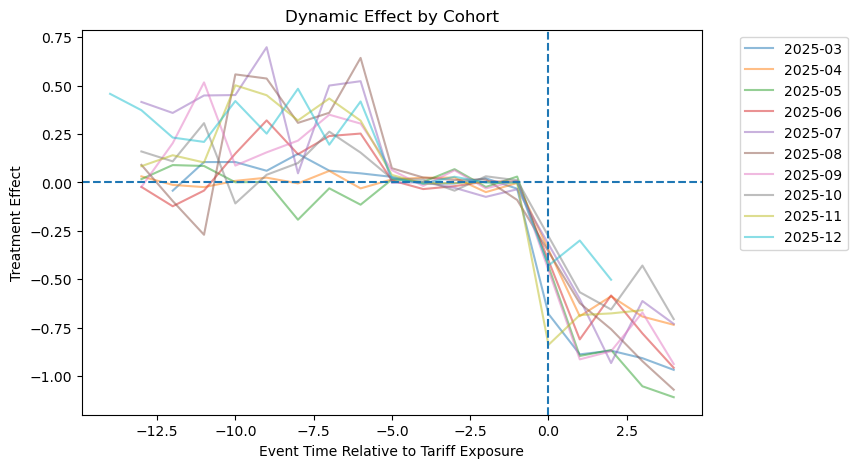


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort     ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 -0.8615 0.0487 -17.7016   0.0000 -0.9569  -0.7661          5
1  2025-04 -0.6761 0.0313 -21.5930   0.0000 -0.7375  -0.6148          4
2  2025-05 -0.9800 0.0592 -16.5589   0.0000 -1.0961  -0.8640          4
3  2025-06 -0.7822 0.0768 -10.1804   0.0000 -0.9327  -0.6316          4
4  2025-07 -0.7188 0.0767  -9.3664   0.0000 -0.8692  -0.5684          4
5  2025-08 -0.8429 0.0972  -8.6690   0.0000 -1.0335  -0.6523          4
6  2025-09 -0.8479 0.0605 -14.0201   0.0000 -0.9664  -0.7294          4
7  2025-10 -0.5891 0.0606  -9.7166   0.0000 -0.7079  -0.4702          4
8  2025-11 -0.7143 0.0416 -17.1751   0.0000 -0.7958  -0.6328          4
9  2025-12 -0.4102 0.0591  -6.9377   0.0000 -0.5261  -0.2943          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort     ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 -0.8112 0.0666 -12.1832   0.000

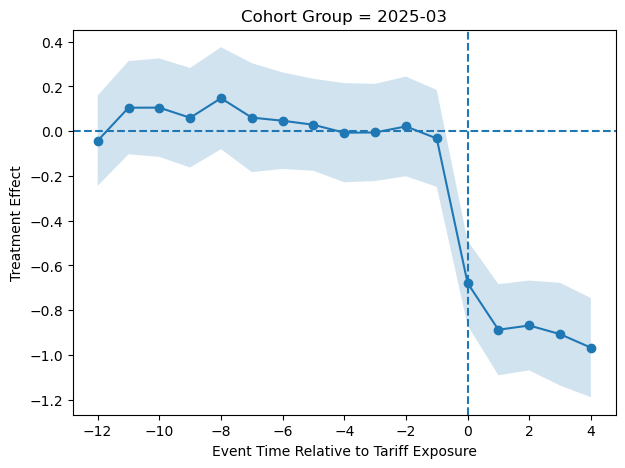

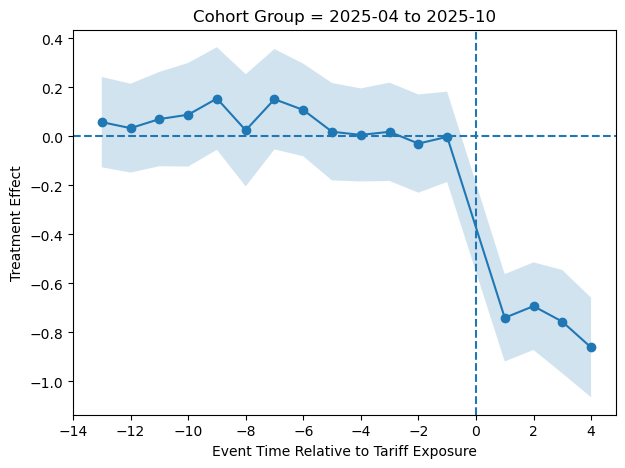

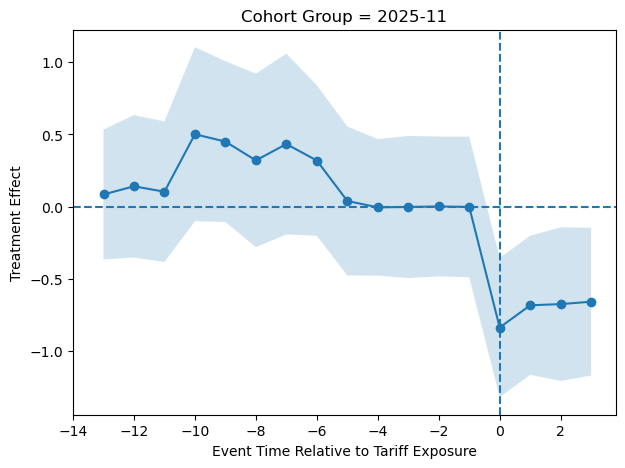

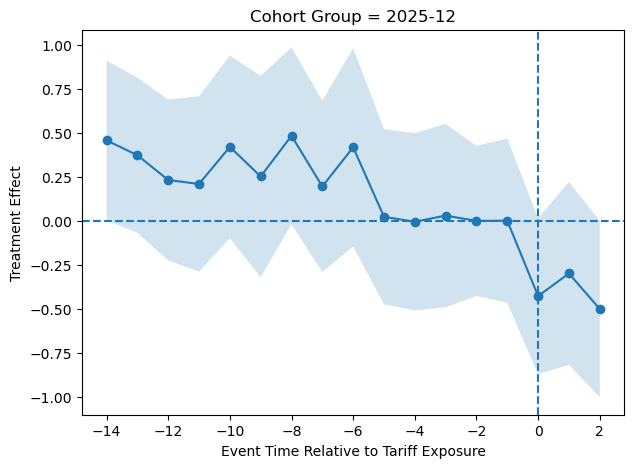

✅ Results saved to: /lakehouse/default/Files/output/inference/matching_high/calendar2_1year_high


In [29]:
df_high = df[df["price"]== "high"] 
results_high =run_full_analysis(df_high)
save_results(results_high, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_high")

StatementMeta(, 75279161-88cc-4d7d-b5c3-bf0d4506d969, 32, Finished, Available, Finished, False)


===== TRANSFORMED EVENT TIME DATA =====
                       aID   cohort TIDPUNKT  treatment  event_time  \
909915  735999166200003237  2025-03  2023-01          1         -26   
909883  735999166200003237  2025-03  2023-02          1         -25   
909853  735999166200003237  2025-03  2023-03          1         -24   
909854  735999166200003237  2025-03  2023-04          1         -23   
909925  735999166200003237  2025-03  2023-05          1         -22   
...                    ...      ...      ...        ...         ...   
207563  735999166200012017  2025-03  2024-08          0          -7   
207631  735999166200012017  2025-03  2024-09          0          -6   
207583  735999166200012017  2025-03  2024-10          0          -5   
207665  735999166200012017  2025-03  2024-11          0          -4   
207599  735999166200012017  2025-03  2024-12          0          -3   

        cohort_event_month  target_month_flag  new_event_time  
909915                   1                

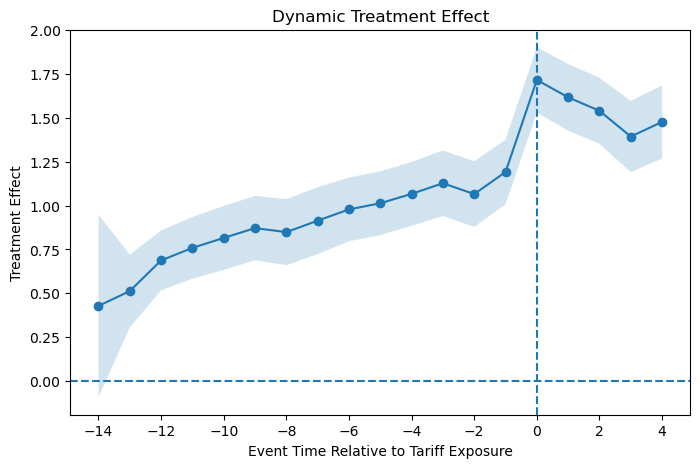


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 0.9451487822236938, 't_stat': 21.19425742828691, 'p_value': 2.866135810825379e-10}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': 1.549248279485793, 'SE': 0.05570636312847984, 't_stat': 27.810975128867113, 'p_value': 0.0, 'CI_low': 1.4400638077539725, 'CI_high': 1.6584327512176134, 'n_periods': 5}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': 1.6249892126798358, 'SE': 0.050932551159634736, 't_stat': 31.904728423807654, 'p_value': 0.0, 'CI_low': 1.5251614124069517, 'CI_high': 1.7248170129527198, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  new_event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03             -12  1.0239 0.1459  7.0197   0.0000        620   
1    2025-03             -11  1.1711 0.1503  7.7910   0.0000        620   
2    2025-03             -10  1.1020 0.1511  7.2910   0.0000        617   
3    2025-03  

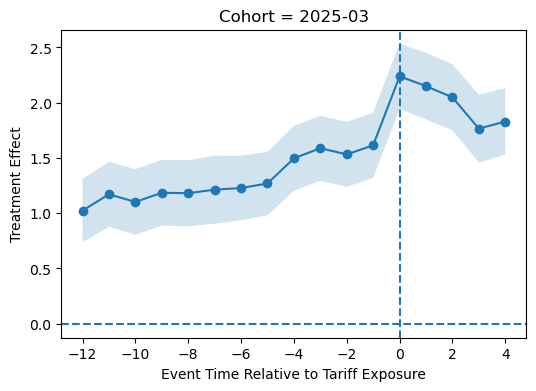

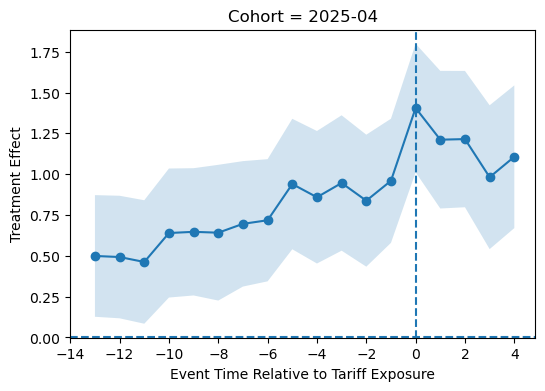

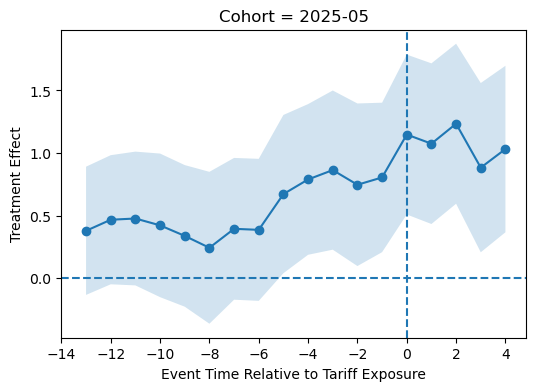

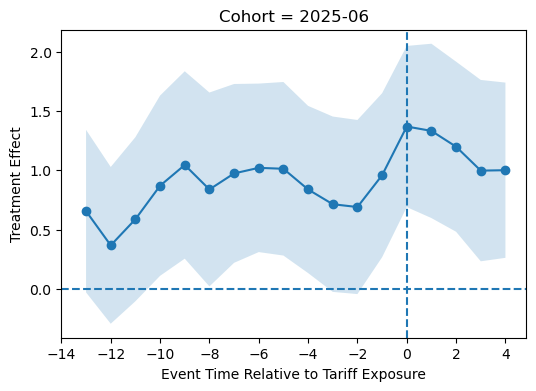

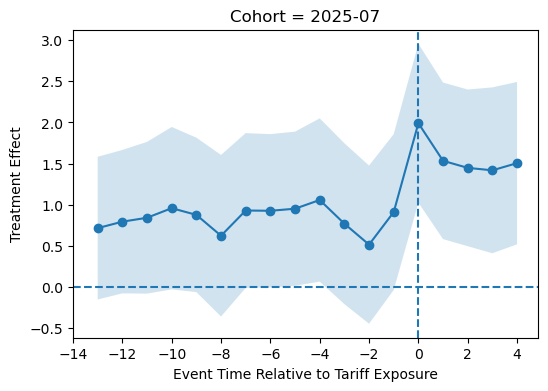

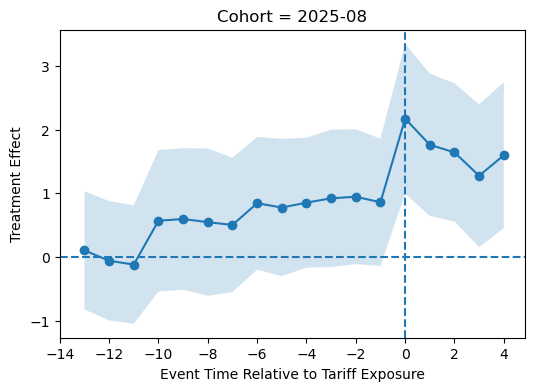

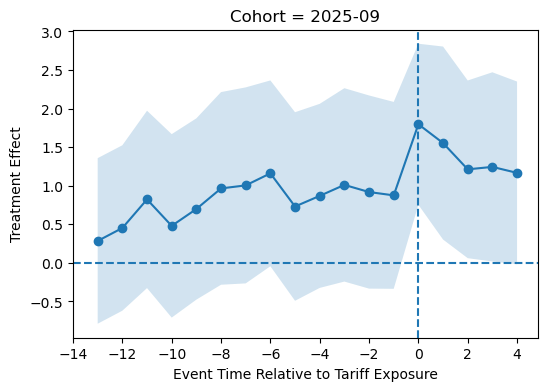

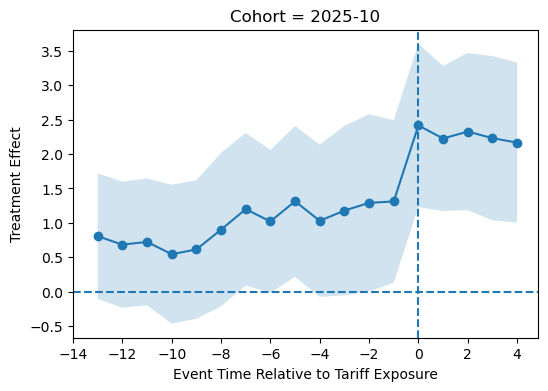

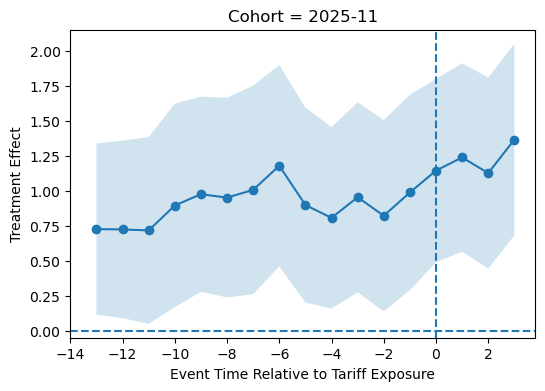

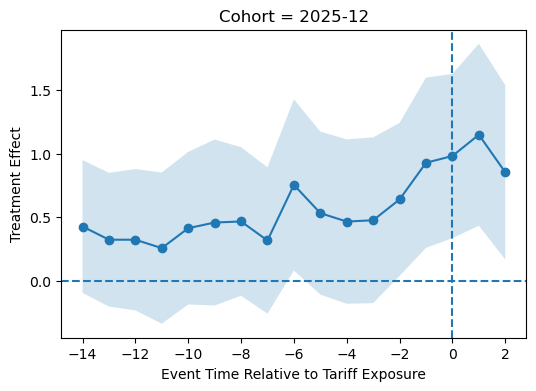

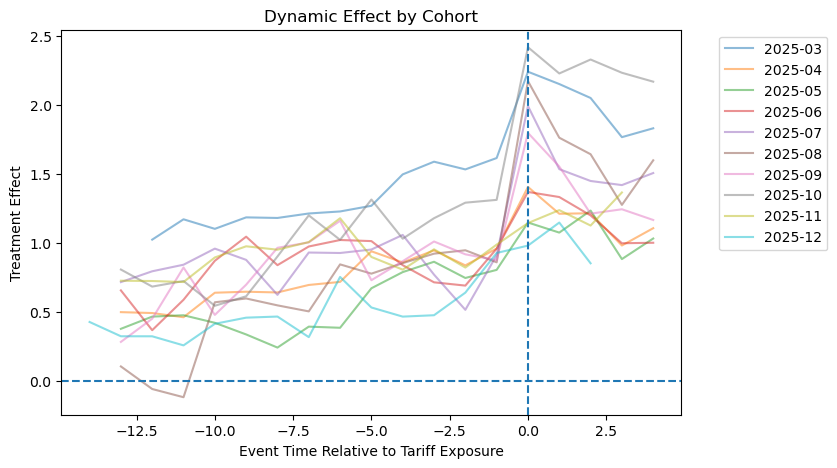


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.0066 0.0910 22.0419   0.0000  1.8282   2.1850          5
1  2025-04 1.1839 0.0699 16.9469   0.0000  1.0470   1.3208          5
2  2025-05 1.0744 0.0588 18.2576   0.0000  0.9591   1.1898          5
3  2025-06 1.1798 0.0789 14.9591   0.0000  1.0253   1.3344          5
4  2025-07 1.5795 0.1048 15.0728   0.0000  1.3741   1.7849          5
5  2025-08 1.6895 0.1448 11.6703   0.0000  1.4058   1.9733          5
6  2025-09 1.3942 0.1214 11.4819   0.0000  1.1562   1.6322          5
7  2025-10 2.2737 0.0439 51.7500   0.0000  2.1876   2.3598          5
8  2025-11 1.2181 0.0548 22.2296   0.0000  1.1107   1.3255          4
9  2025-12 0.9936 0.0853 11.6484   0.0000  0.8264   1.1608          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.1459 0.0549 39.1083   0.0000  2.0384   2.2535        

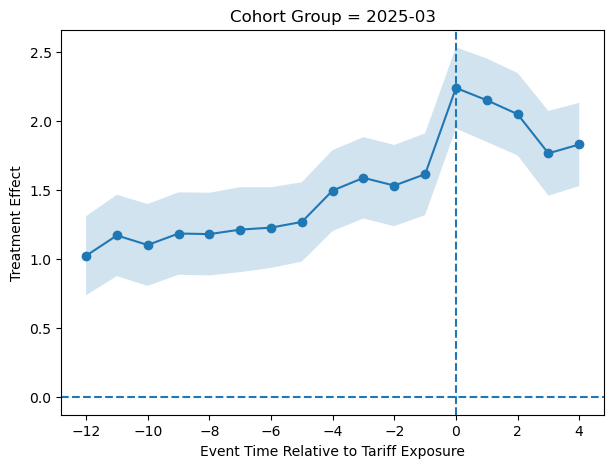

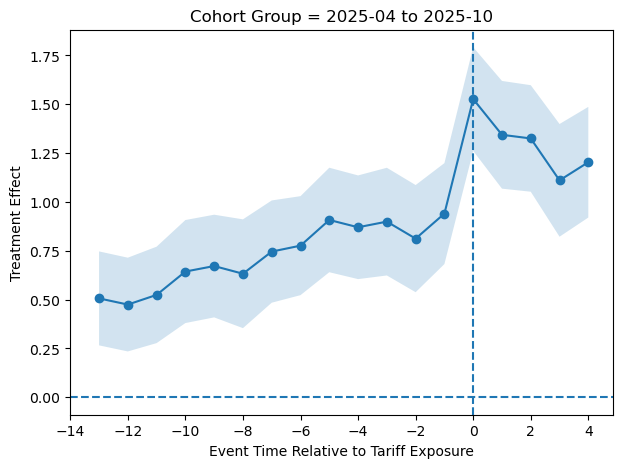

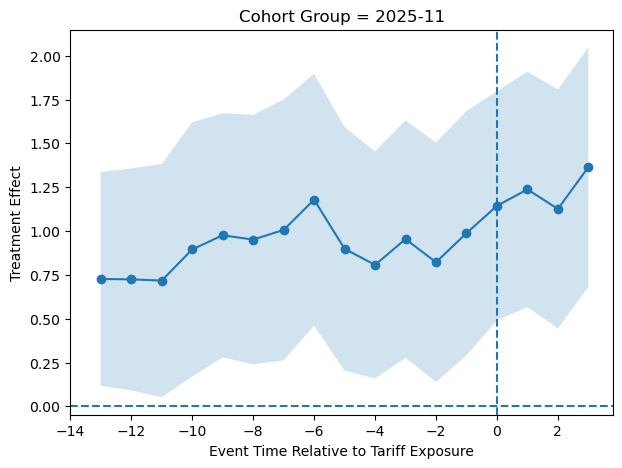

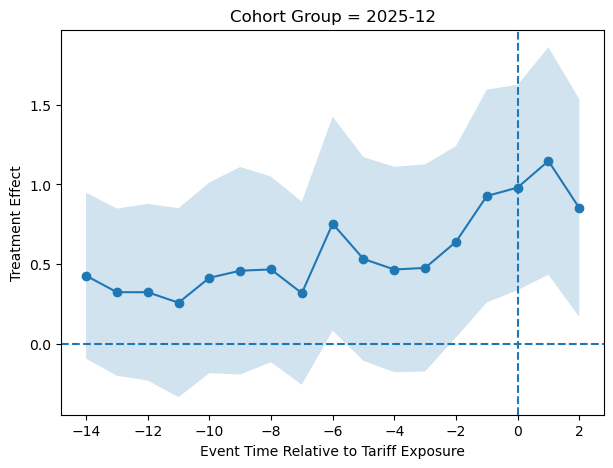

✅ Results saved to: /lakehouse/default/Files/output/inference/matching_high/calendar2_1year_all


In [30]:
df_all = df[df["price"]== "all"] 
results_all = run_full_analysis(df_all)
save_results(results_all, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_all")

StatementMeta(, 75279161-88cc-4d7d-b5c3-bf0d4506d969, 33, Finished, Available, Finished, False)


===== TRANSFORMED EVENT TIME DATA =====
                       aID   cohort TIDPUNKT  treatment  event_time  \
909888  735999166200003237  2025-03  2023-01          1         -26   
909923  735999166200003237  2025-03  2023-02          1         -25   
909906  735999166200003237  2025-03  2023-03          1         -24   
909878  735999166200003237  2025-03  2023-04          1         -23   
909880  735999166200003237  2025-03  2023-05          1         -22   
...                    ...      ...      ...        ...         ...   
207491  735999166200012017  2025-03  2024-08          0          -7   
207613  735999166200012017  2025-03  2024-09          0          -6   
207587  735999166200012017  2025-03  2024-10          0          -5   
207607  735999166200012017  2025-03  2024-11          0          -4   
207507  735999166200012017  2025-03  2024-12          0          -3   

        cohort_event_month  target_month_flag  new_event_time  
909888                   1                

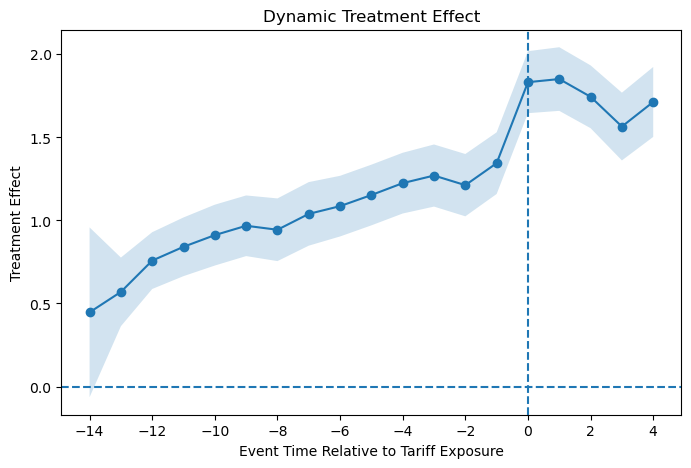


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 1.0628055441375417, 't_stat': 20.120210287871, 'p_value': 5.0115087126687e-10}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': 1.741474671831222, 'SE': 0.051076044732808495, 't_stat': 34.095722974269236, 'p_value': 0.0, 'CI_low': 1.6413656241549173, 'CI_high': 1.8415837195075266, 'n_periods': 5}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': 1.8094984806522978, 'SE': 0.03292023913977054, 't_stat': 54.96614022059958, 'p_value': 0.0, 'CI_low': 1.7449748119383475, 'CI_high': 1.8740221493662481, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  new_event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03             -12  1.1388 0.1464  7.7769   0.0000        620   
1    2025-03             -11  1.2752 0.1509  8.4482   0.0000        620   
2    2025-03             -10  1.2599 0.1526  8.2559   0.0000        617   
3    2025-03       

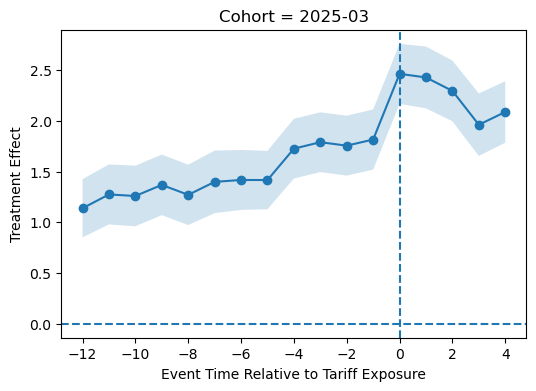

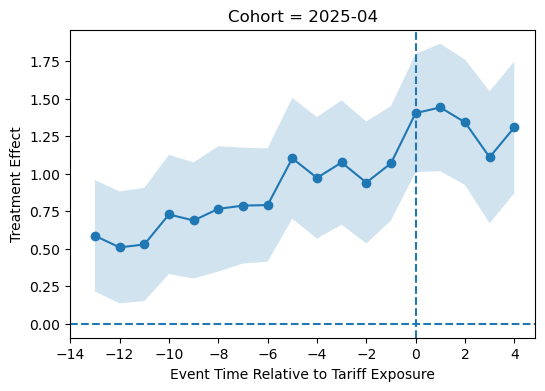

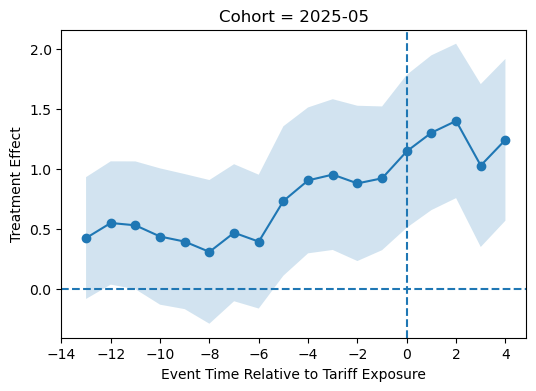

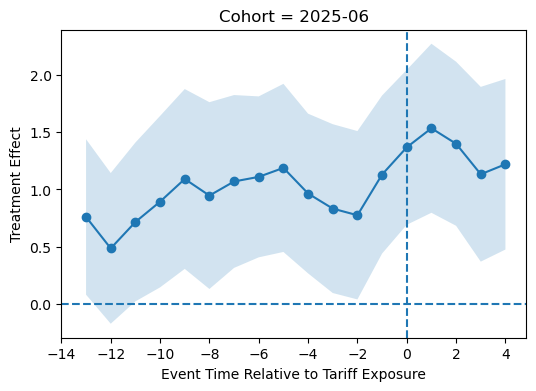

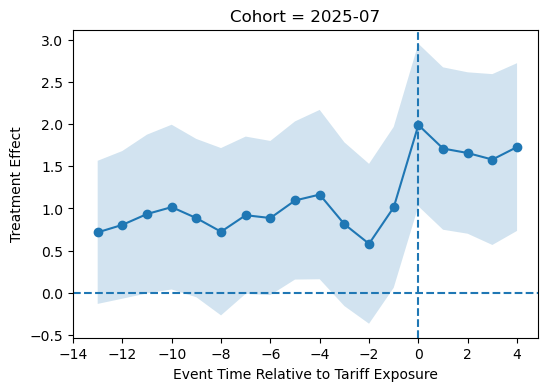

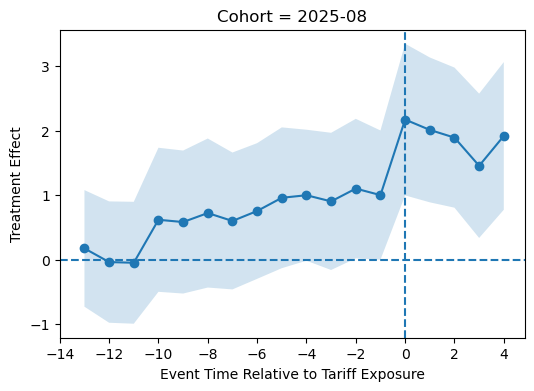

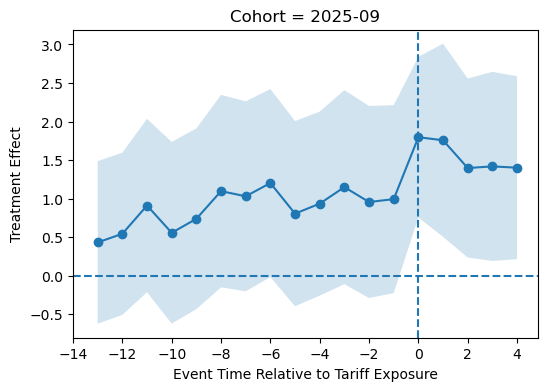

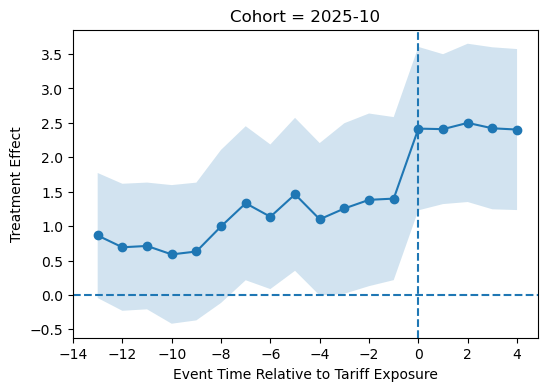

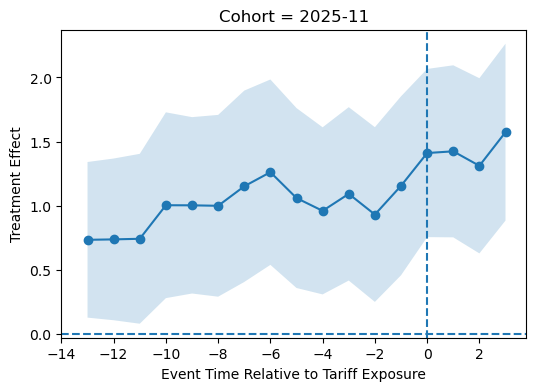

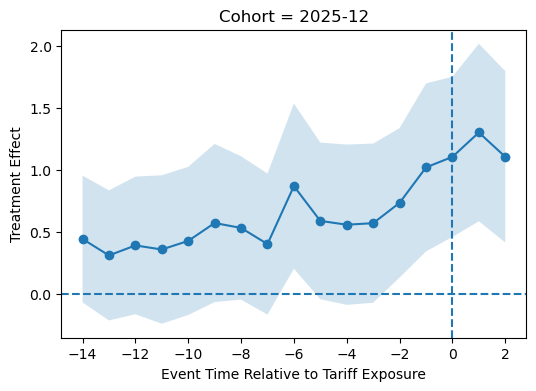

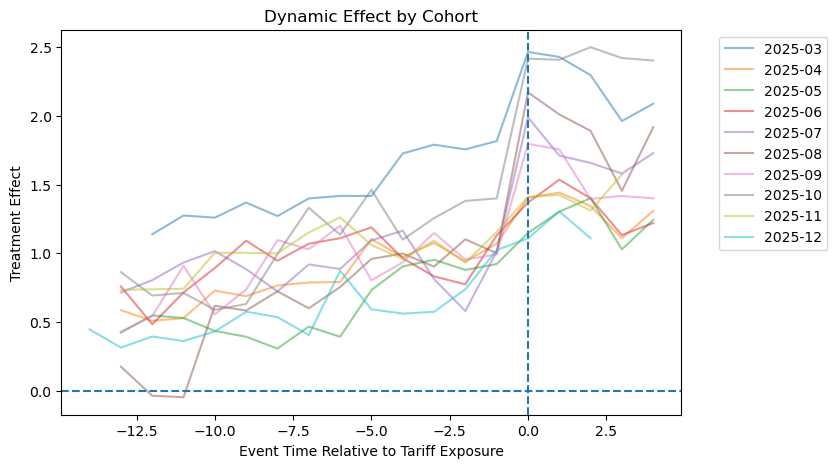


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort    ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.2485 0.0972  23.1233   0.0000  2.0579   2.4390          5
1  2025-04 1.3221 0.0578  22.8771   0.0000  1.2088   1.4354          5
2  2025-05 1.2251 0.0641  19.1110   0.0000  1.0995   1.3508          5
3  2025-06 1.3318 0.0706  18.8754   0.0000  1.1935   1.4701          5
4  2025-07 1.7338 0.0692  25.0487   0.0000  1.5981   1.8695          5
5  2025-08 1.8891 0.1191  15.8603   0.0000  1.6557   2.1226          5
6  2025-09 1.5535 0.0914  17.0041   0.0000  1.3744   1.7325          5
7  2025-10 2.4297 0.0178 136.5455   0.0000  2.3948   2.4646          5
8  2025-11 1.4301 0.0541  26.4432   0.0000  1.3241   1.5362          4
9  2025-12 1.1746 0.0654  17.9674   0.0000  1.0465   1.3028          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.3969 0.0513 46.7345   0.0000  2.2964   2.4

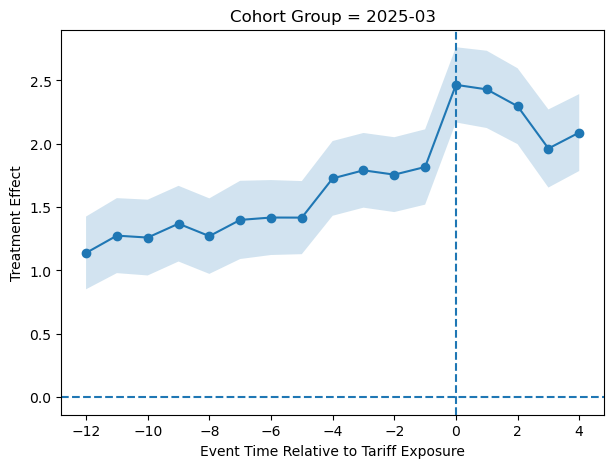

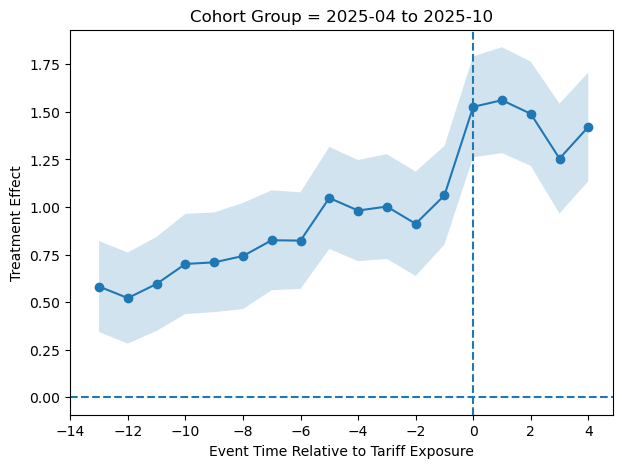

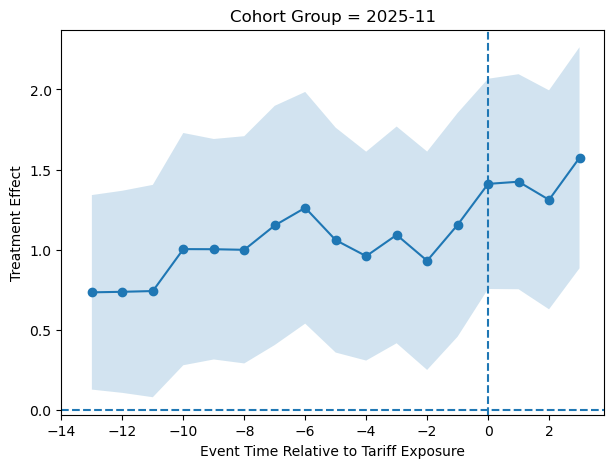

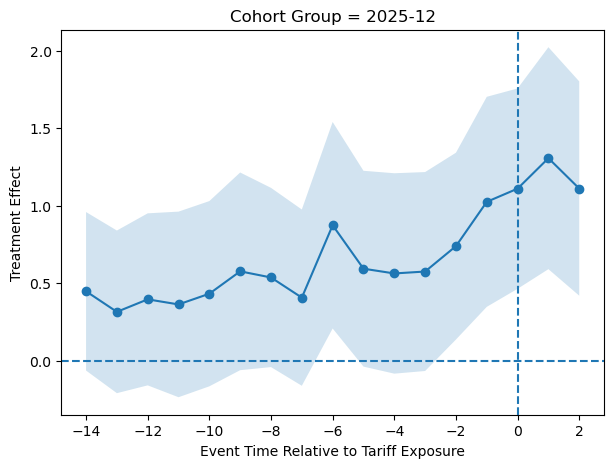

✅ Results saved to: /lakehouse/default/Files/output/inference/matching_high/calendar2_1year_low


In [31]:
df_low = df[df["price"]== "low"] 
results_low = run_full_analysis(df_low)
save_results(results_low, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_low")

In [32]:
# Change here !!!
match_method = "summary_4"
# option: calendar, calendar2, summary_1, summary_2, summary_3, summary_4, summary_season, summary_season_2, time_series
# check: time_series, calendar(matching result is not that good), summary_4, summary_season_2


# 1. Read data
matches = pd.read_parquet(f"/lakehouse/default/Files/output/matching_high/{match_method}/matches")
month_result= pd.read_parquet("/lakehouse/default/Files/month_data")

# 2. create matched panel
df = build_matched_panel(matches, month_result)

StatementMeta(, 75279161-88cc-4d7d-b5c3-bf0d4506d969, 34, Finished, Available, Finished, False)

StatementMeta(, 75279161-88cc-4d7d-b5c3-bf0d4506d969, 35, Finished, Available, Finished, False)


===== TRANSFORMED EVENT TIME DATA =====
                       aID   cohort TIDPUNKT  treatment  event_time  \
697493  735999166200003220  2025-03  2023-01          0         -26   
697459  735999166200003220  2025-03  2023-02          0         -25   
697563  735999166200003220  2025-03  2023-03          0         -24   
697533  735999166200003220  2025-03  2023-11          0         -16   
697479  735999166200003220  2025-03  2023-12          0         -15   
...                    ...      ...      ...        ...         ...   
508049  735999166200013373  2025-03  2025-01          0          -2   
508070  735999166200013373  2025-03  2025-02          0          -1   
508091  735999166200013373  2025-03  2025-03          0           0   
508018  735999166200013373  2025-03  2025-11          0           8   
508021  735999166200013373  2025-03  2025-12          0           9   

        cohort_event_month  target_month_flag  new_event_time  
697493                   1                

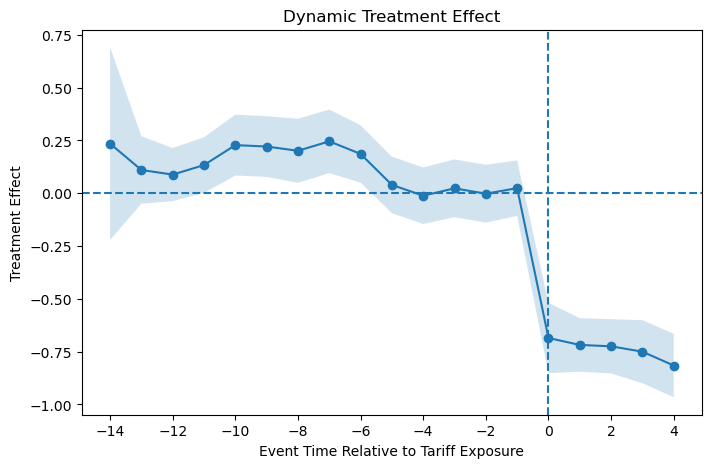


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 0.11491182399336079, 't_stat': 4.03947025969279, 'p_value': 0.0019502408385631553}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': -0.7387495183289137, 'SE': 0.021814640262414014, 't_stat': -33.86484991007426, 'p_value': 0.0, 'CI_low': -0.7815062132432451, 'CI_high': -0.6959928234145822, 'n_periods': 5}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': -0.7093606260138424, 'SE': 0.012203370014929577, 't_stat': -58.12825679677107, 'p_value': 0.0, 'CI_low': -0.7332792312431043, 'CI_high': -0.6854420207845805, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  new_event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03             -12  0.1343 0.1025  1.3112   0.1898        620   
1    2025-03             -11  0.2216 0.1059  2.0927   0.0364        620   
2    2025-03             -10  0.2829 0.1115  2.5379   0.0112        617   
3    2

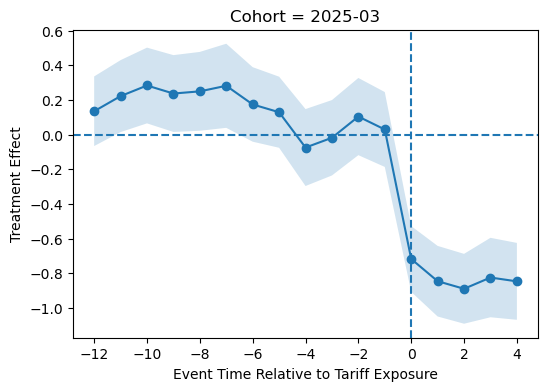

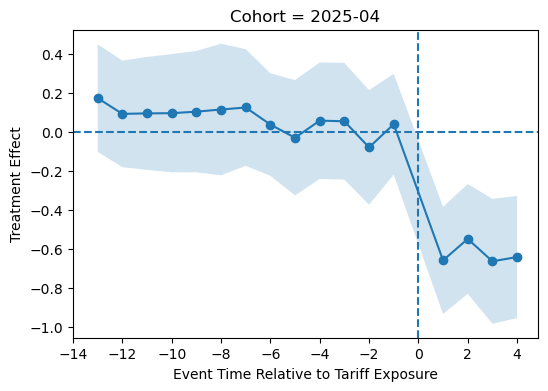

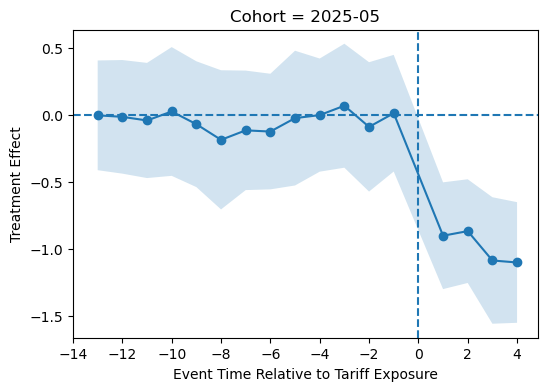

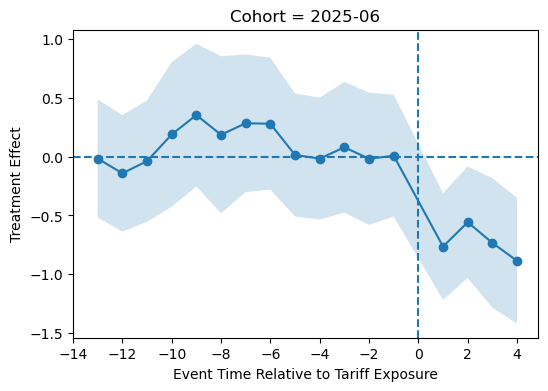

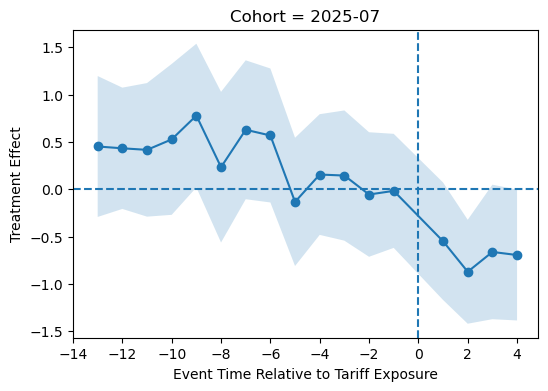

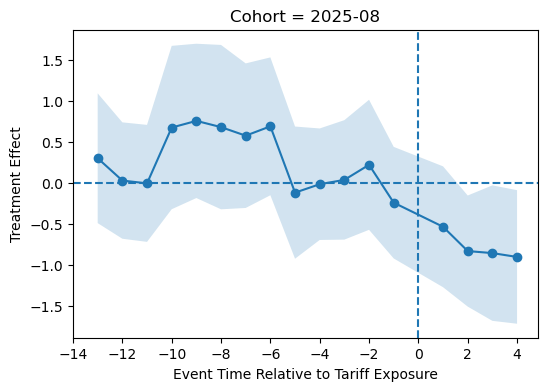

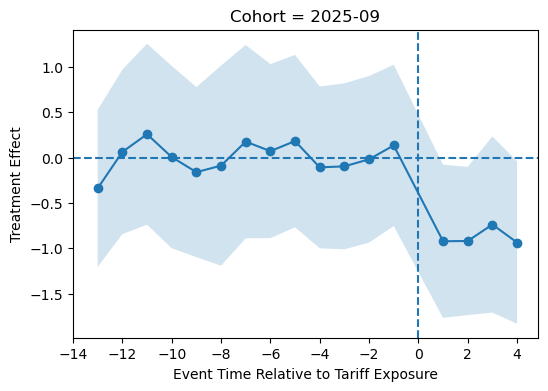

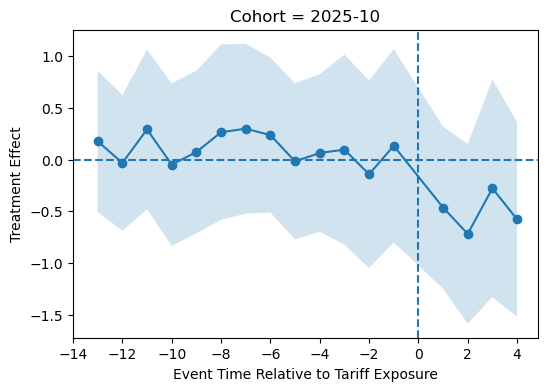

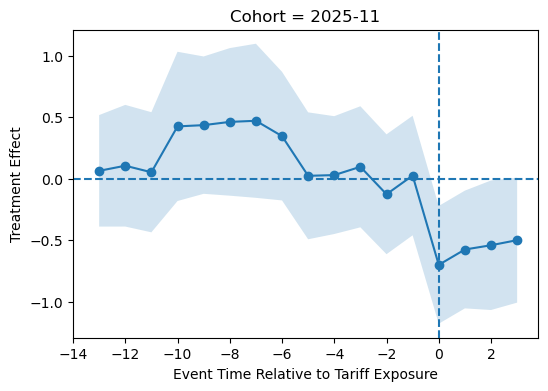

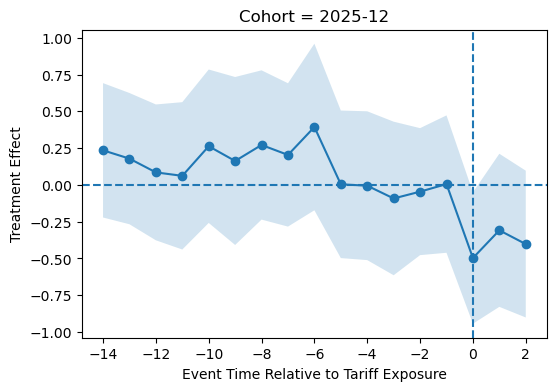

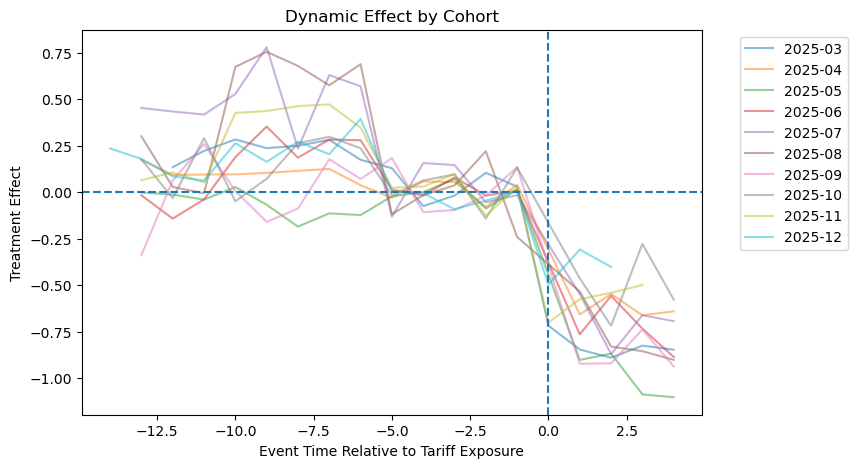


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort     ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 -0.8253 0.0288 -28.6387   0.0000 -0.8818  -0.7689          5
1  2025-04 -0.6272 0.0269 -23.3546   0.0000 -0.6798  -0.5745          4
2  2025-05 -0.9901 0.0611 -16.2088   0.0000 -1.1098  -0.8704          4
3  2025-06 -0.7356 0.0678 -10.8449   0.0000 -0.8686  -0.6027          4
4  2025-07 -0.6935 0.0668 -10.3799   0.0000 -0.8244  -0.5625          4
5  2025-08 -0.7804 0.0833  -9.3725   0.0000 -0.9436  -0.6172          4
6  2025-09 -0.8795 0.0473 -18.6135   0.0000 -0.9721  -0.7869          4
7  2025-10 -0.5093 0.0930  -5.4782   0.0000 -0.6915  -0.3271          4
8  2025-11 -0.5792 0.0433 -13.3694   0.0000 -0.6642  -0.4943          4
9  2025-12 -0.4026 0.0544  -7.3995   0.0000 -0.5092  -0.2959          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort     ATT     SE    t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 -0.8181 0.0516  -15.8542   0.0

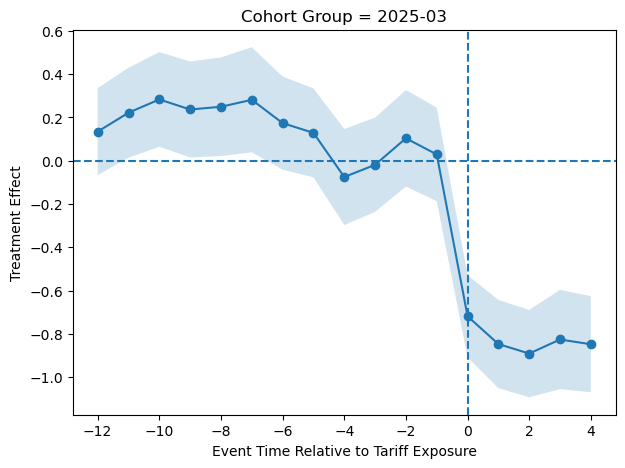

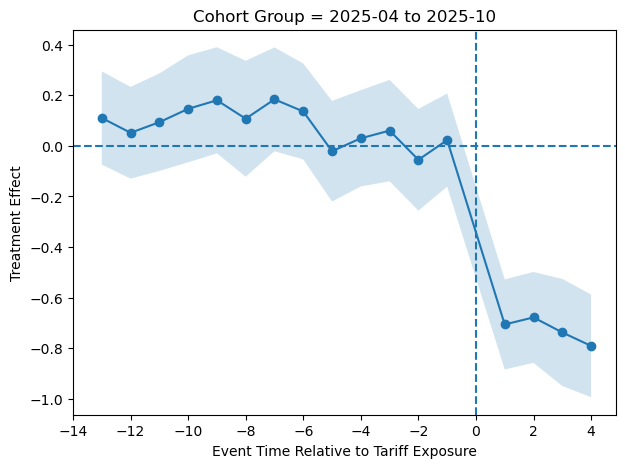

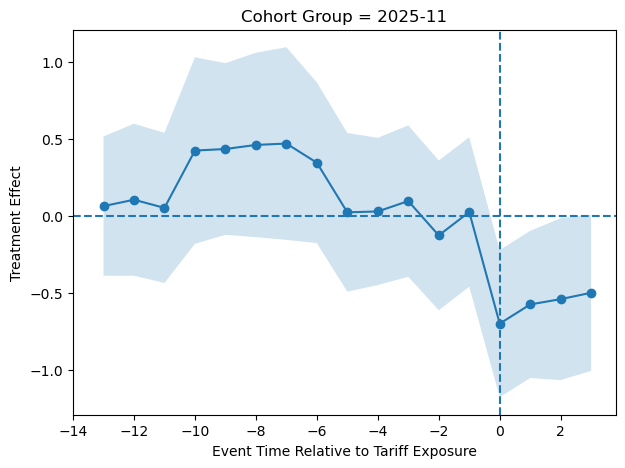

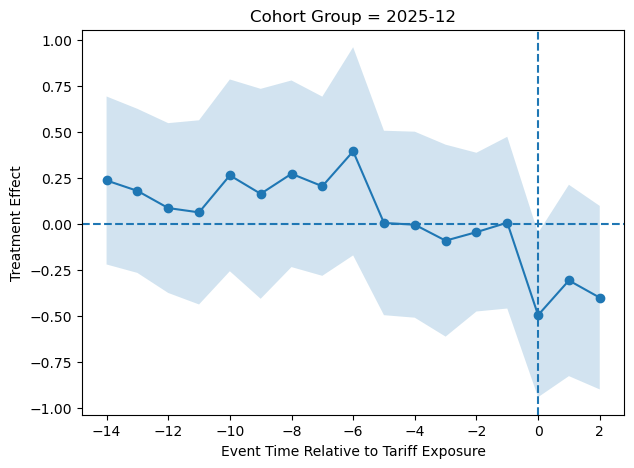

✅ Results saved to: /lakehouse/default/Files/output/inference/matching_high/summary_4_high


In [33]:
df_high = df[df["price"]== "high"] 
run_full_analysis(df_high)
save_results(results_high, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_high")

StatementMeta(, 75279161-88cc-4d7d-b5c3-bf0d4506d969, 36, Finished, Available, Finished, False)


===== TRANSFORMED EVENT TIME DATA =====
                       aID   cohort TIDPUNKT  treatment  event_time  \
697577  735999166200003220  2025-03  2023-01          0         -26   
697409  735999166200003220  2025-03  2023-02          0         -25   
697439  735999166200003220  2025-03  2023-03          0         -24   
697575  735999166200003220  2025-03  2023-04          0         -23   
697581  735999166200003220  2025-03  2023-05          0         -22   
...                    ...      ...      ...        ...         ...   
241644  735999166200004203  2025-03  2024-08          0          -7   
241641  735999166200004203  2025-03  2024-09          0          -6   
241626  735999166200004203  2025-03  2024-10          0          -5   
241658  735999166200004203  2025-03  2024-11          0          -4   
241628  735999166200004203  2025-03  2024-12          0          -3   

        cohort_event_month  target_month_flag  new_event_time  
697577                   1                

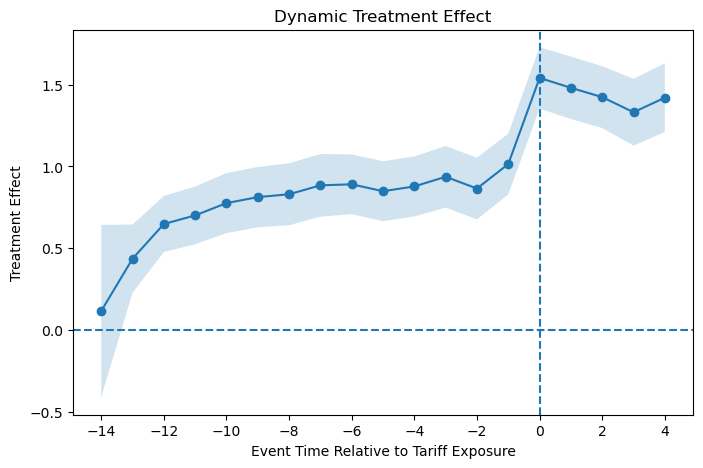


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 0.8408720038005519, 't_stat': 29.452155767241443, 'p_value': 8.146522214733064e-12}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': 1.4393113162020463, 'SE': 0.034840808239231004, 't_stat': 41.31107712310104, 'p_value': 0.0, 'CI_low': 1.3710233320531535, 'CI_high': 1.5075993003509391, 'n_periods': 5}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': 1.481650242187713, 'SE': 0.033892734713975525, 't_stat': 43.715865795177656, 'p_value': 0.0, 'CI_low': 1.415220482148321, 'CI_high': 1.5480800022271048, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  new_event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03             -12  1.0778 0.1459  7.3890   0.0000        620   
1    2025-03             -11  1.1875 0.1502  7.9052   0.0000        620   
2    2025-03             -10  1.1523 0.1509  7.6339   0.0000        617   
3    2025-03  

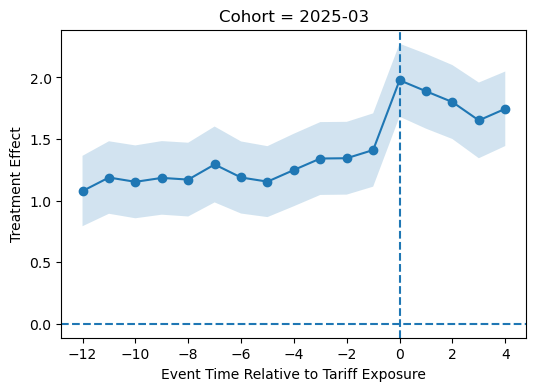

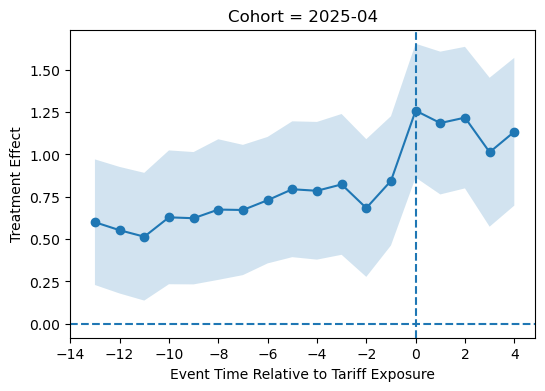

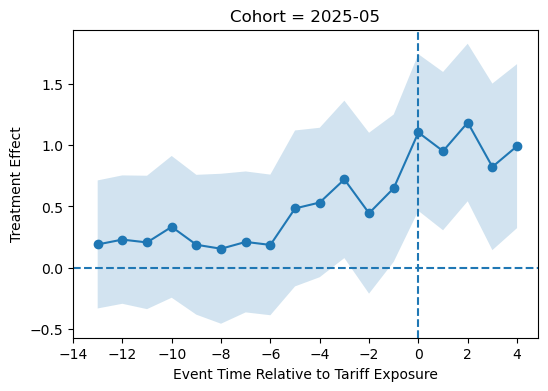

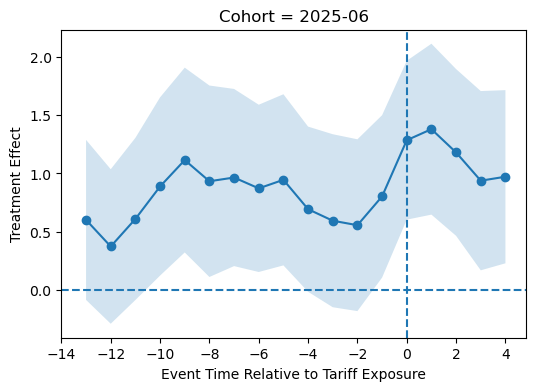

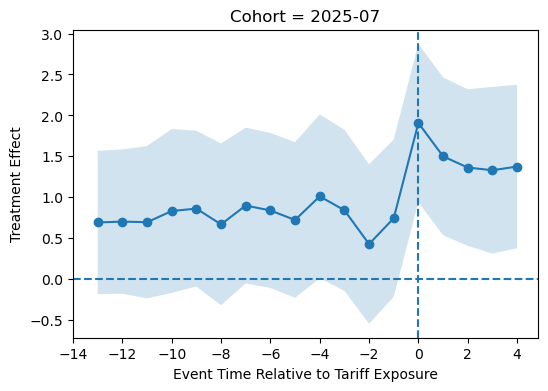

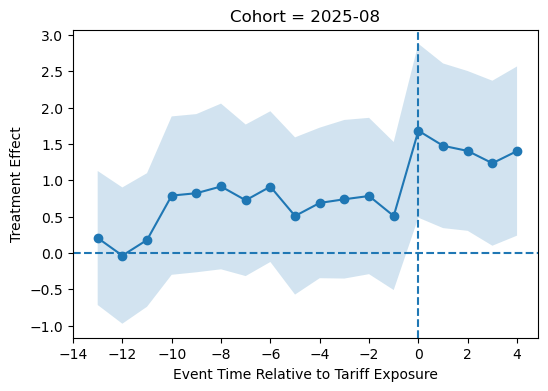

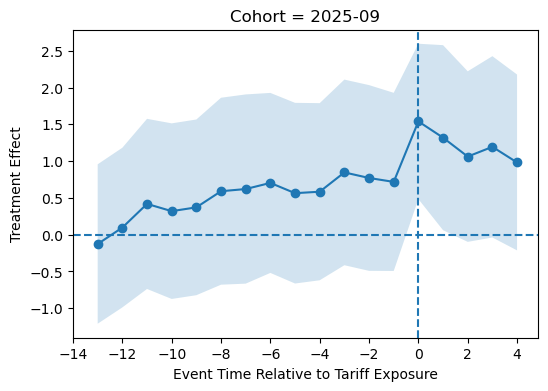

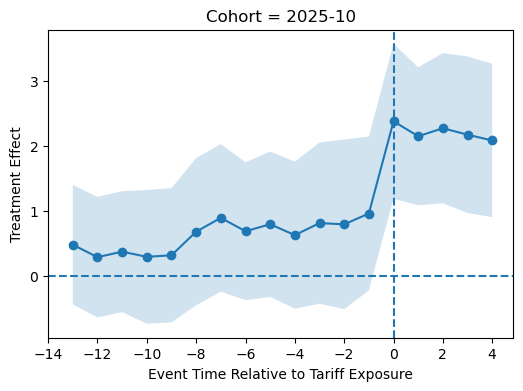

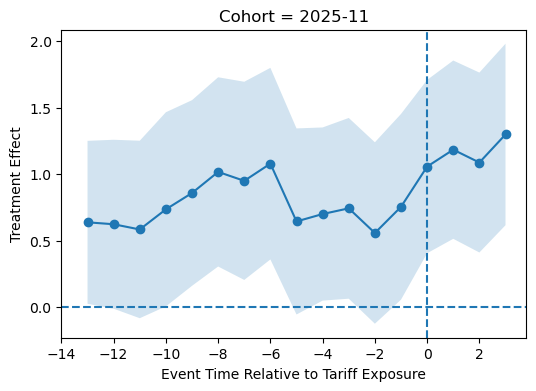

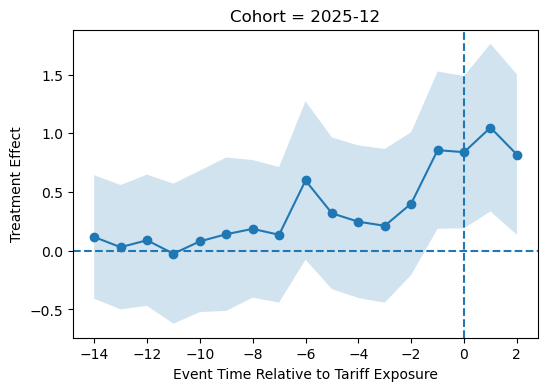

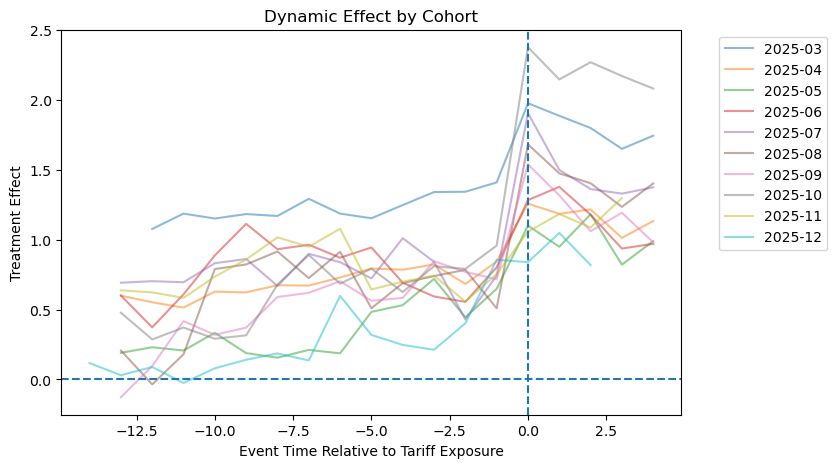


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 1.8127 0.0564 32.1476   0.0000  1.7021   1.9232          5
1  2025-04 1.1622 0.0424 27.4089   0.0000  1.0791   1.2453          5
2  2025-05 1.0094 0.0623 16.2114   0.0000  0.8874   1.1315          5
3  2025-06 1.1504 0.0862 13.3471   0.0000  0.9815   1.3194          5
4  2025-07 1.4956 0.1070 13.9814   0.0000  1.2860   1.7053          5
5  2025-08 1.4408 0.0724 19.9076   0.0000  1.2989   1.5826          5
6  2025-09 1.2190 0.0986 12.3568   0.0000  1.0256   1.4123          5
7  2025-10 2.2111 0.0518 42.7037   0.0000  2.1096   2.3126          5
8  2025-11 1.1573 0.0545 21.2281   0.0000  1.0505   1.2642          4
9  2025-12 0.9026 0.0735 12.2823   0.0000  0.7586   1.0467          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 1.8888 0.0512 36.9014   0.0000  1.7884   1.9891        

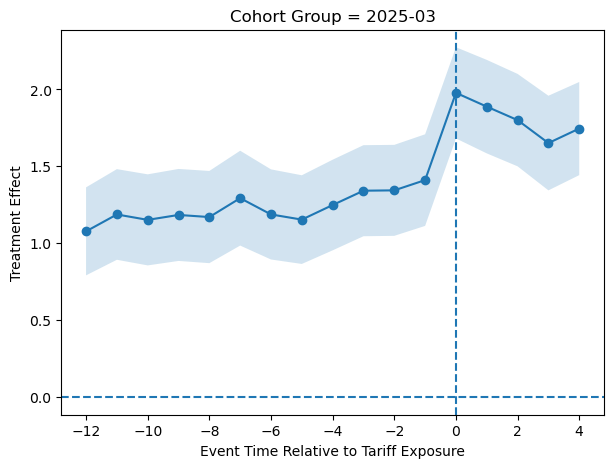

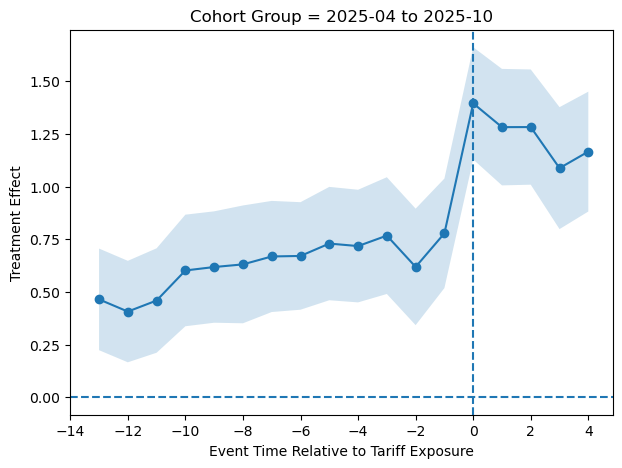

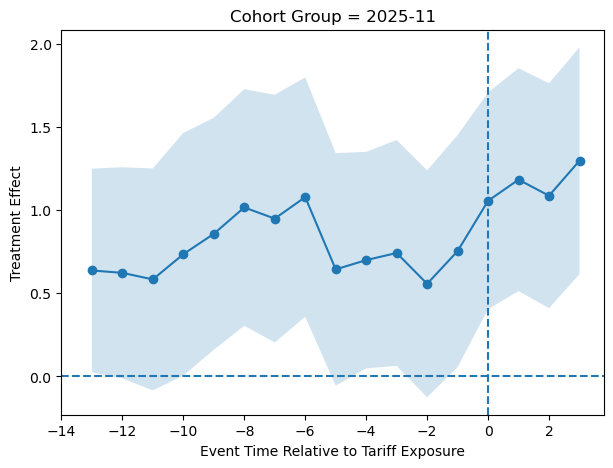

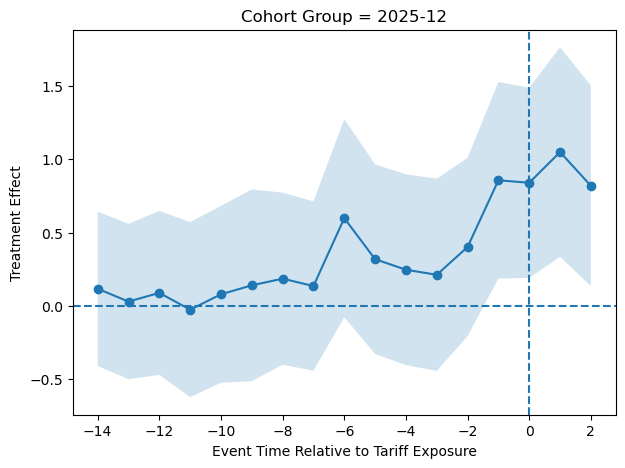

✅ Results saved to: /lakehouse/default/Files/output/inference/matching_high/summary_4_all


In [34]:
df_all = df[df["price"]== "all"] 
run_full_analysis(df_all)
save_results(results_all, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_all")

StatementMeta(, 75279161-88cc-4d7d-b5c3-bf0d4506d969, 37, Finished, Available, Finished, False)


===== TRANSFORMED EVENT TIME DATA =====
                       aID   cohort TIDPUNKT  treatment  event_time  \
697497  735999166200003220  2025-03  2023-01          0         -26   
697465  735999166200003220  2025-03  2023-02          0         -25   
697411  735999166200003220  2025-03  2023-03          0         -24   
697489  735999166200003220  2025-03  2023-04          0         -23   
697481  735999166200003220  2025-03  2023-05          0         -22   
...                    ...      ...      ...        ...         ...   
241689  735999166200004203  2025-03  2024-08          0          -7   
241690  735999166200004203  2025-03  2024-09          0          -6   
241627  735999166200004203  2025-03  2024-10          0          -5   
241619  735999166200004203  2025-03  2024-11          0          -4   
241691  735999166200004203  2025-03  2024-12          0          -3   

        cohort_event_month  target_month_flag  new_event_time  
697497                   1                

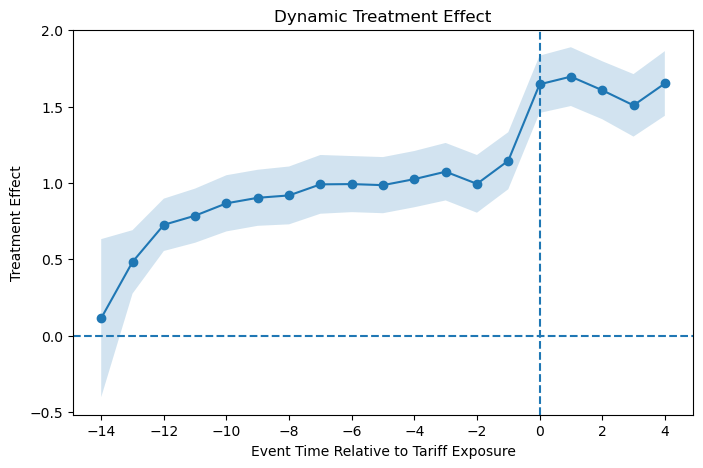


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 0.9509931574182321, 't_stat': 27.9158987849086, 'p_value': 1.4580477453476364e-11}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': 1.6220573604182804, 'SE': 0.031713745815293404, 't_stat': 51.146823521429354, 'p_value': 0.0, 'CI_low': 1.5598984186203053, 'CI_high': 1.6842163022162555, 'n_periods': 5}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': 1.6500743018626594, 'SE': 0.025757640488273906, 't_stat': 64.06154719854294, 'p_value': 0.0, 'CI_low': 1.5995893265056425, 'CI_high': 1.7005592772196763, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  new_event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03             -12  1.1902 0.1465  8.1263   0.0000        620   
1    2025-03             -11  1.3033 0.1509  8.6370   0.0000        620   
2    2025-03             -10  1.2979 0.1524  8.5154   0.0000        617   
3    2025-03 

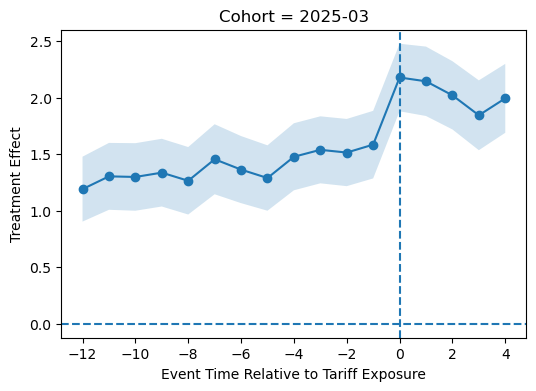

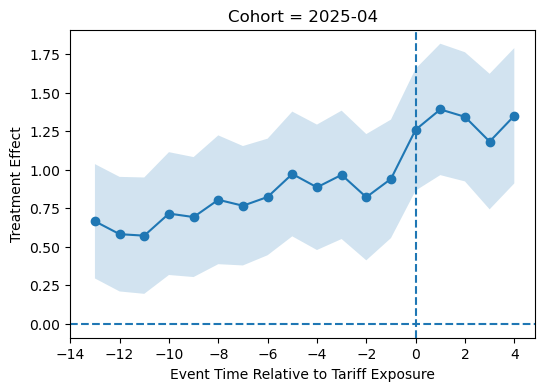

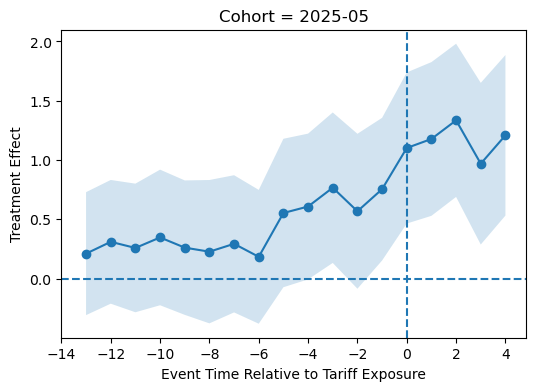

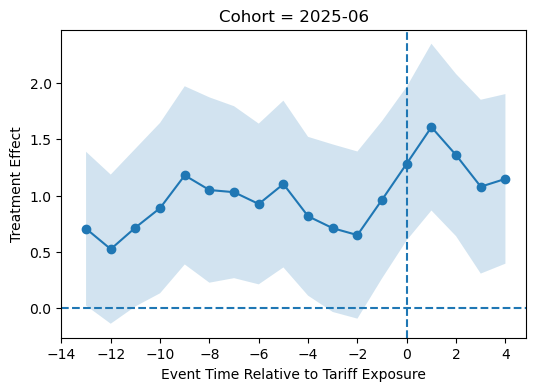

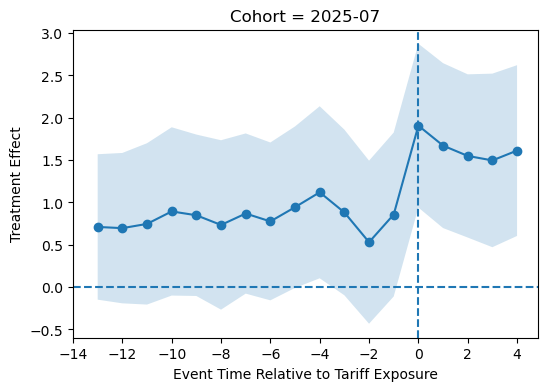

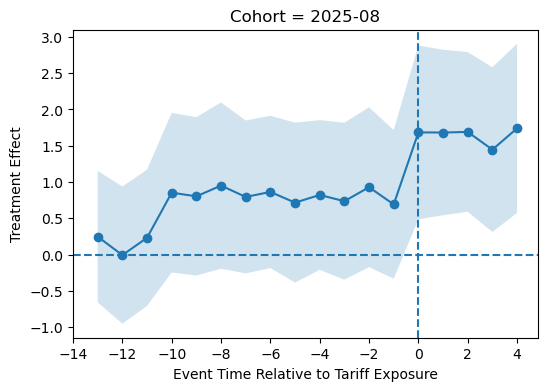

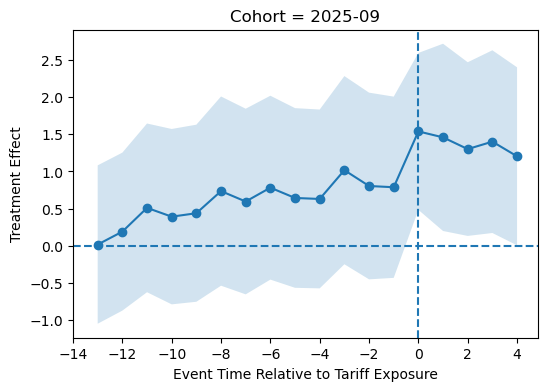

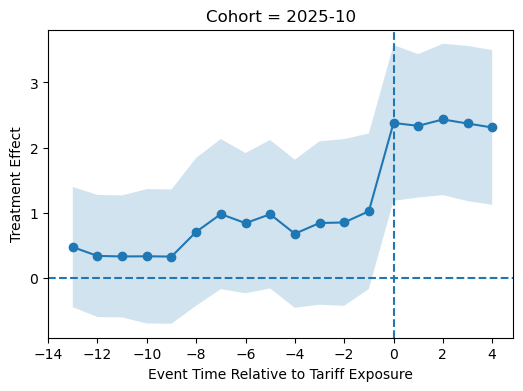

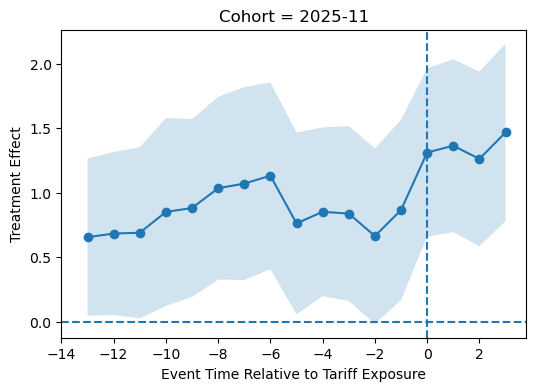

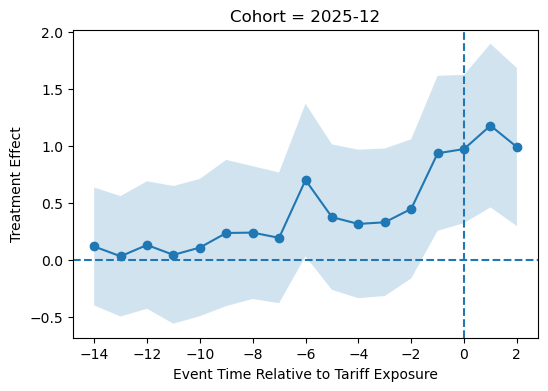

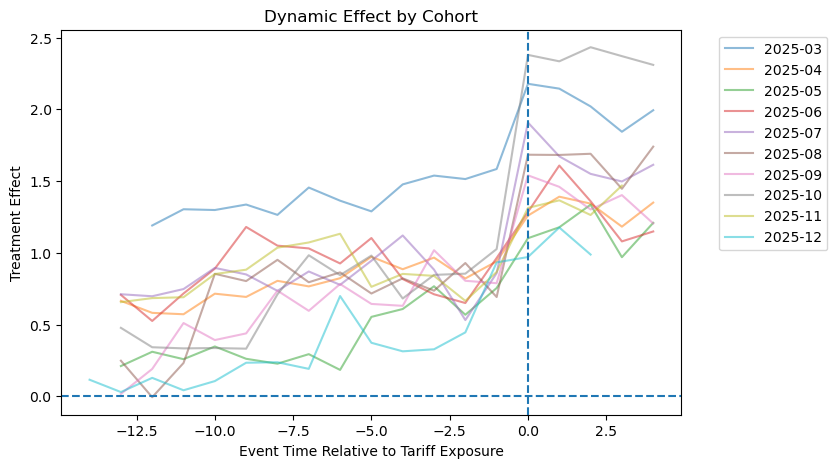


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort    ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.0357 0.0595  34.2041   0.0000  1.9190   2.1523          5
1  2025-04 1.3049 0.0374  34.8785   0.0000  1.2316   1.3782          5
2  2025-05 1.1584 0.0605  19.1546   0.0000  1.0399   1.2769          5
3  2025-06 1.2959 0.0922  14.0480   0.0000  1.1151   1.4767          5
4  2025-07 1.6479 0.0713  23.1122   0.0000  1.5082   1.7877          5
5  2025-08 1.6481 0.0517  31.9086   0.0000  1.5469   1.7493          5
6  2025-09 1.3814 0.0589  23.4719   0.0000  1.2660   1.4968          5
7  2025-10 2.3651 0.0210 112.6480   0.0000  2.3240   2.4063          5
8  2025-11 1.3524 0.0439  30.8013   0.0000  1.2664   1.4385          4
9  2025-12 1.0447 0.0659  15.8553   0.0000  0.9155   1.1738          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort    ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.1138 0.0479  44.1101   0.0000  2.0199   2

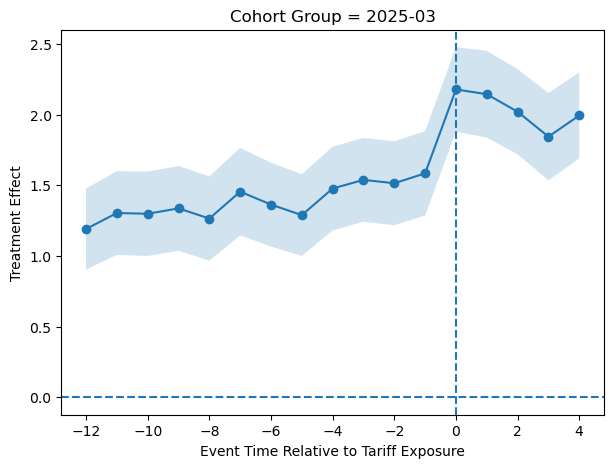

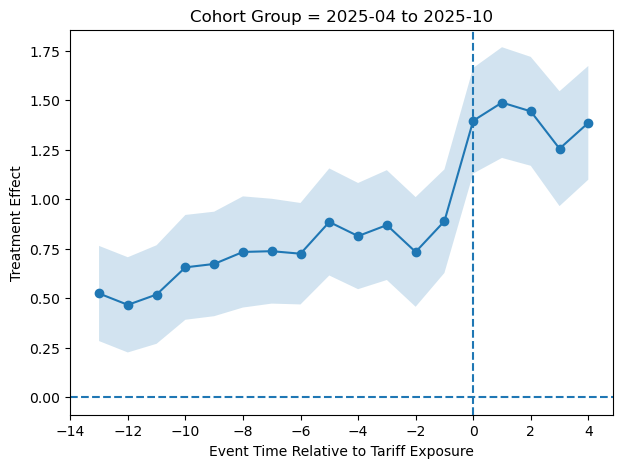

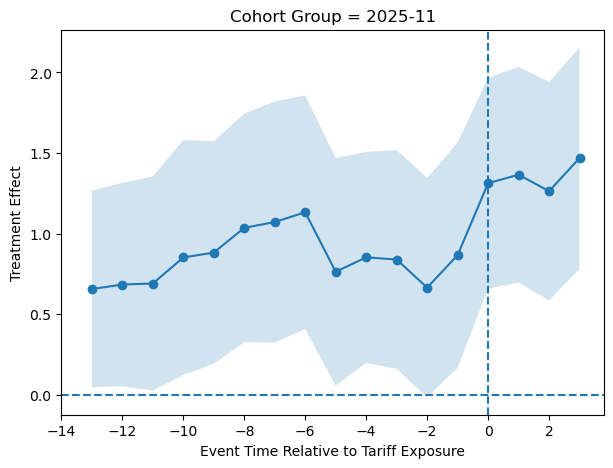

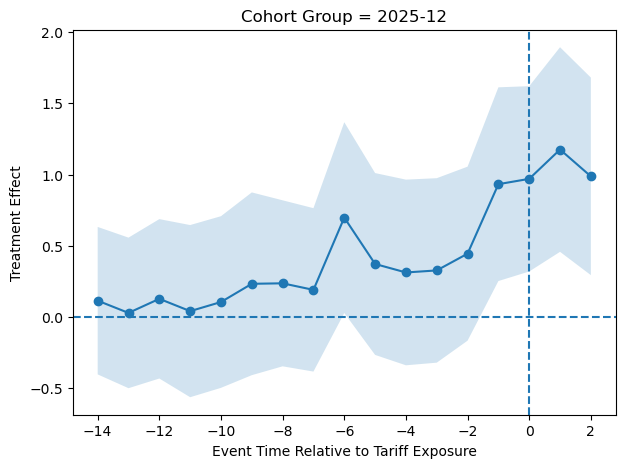

✅ Results saved to: /lakehouse/default/Files/output/inference/matching_high/summary_4_low


In [35]:
df_low = df[df["price"]== "low"] 
run_full_analysis(df_low)
save_results(results_low, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_low")